## Notebook for Plotting Turtle Sensor Data

In [7]:
#!/usr/bin/env python3
import sys
import os
import glob
import re
import cv2
import numpy as np
import matplotlib
matplotlib.use('TkAgg')  # Try this backend for displaying plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Slider, Button
# from tqdm import tqdm  # For progress bars (install with pip install tqdm if needed)
import transforms3d.euler as euler
print(f"OpenCV version: {cv2.__version__}")
import tqdm

OpenCV version: 4.12.0


### Turtle Data Keys

*Shape format: (timesteps, features) where n = number of samples*

- `q` (n, 10) — Joint positions (radians)
- `dq` (n, 10) — Joint velocities (rad/s)
- `t` (n,) — Timestamps (seconds)
- `nav_u` (n, 4) — Navigation control signals from planner

    - [velocity, roll, pitch for front flippers, yaw, pitch for rear flippers]
    - technically it should be (n,5) but we don't record the pitch for rear flippers
- `u` (n, 10) — Actuator motor control signal (radians)

    - has to be passed into grab_arm_current() to ensure we pass in safe currents to the motors
- `input` (n, 10) — Motor current commands (dynamixel units)

    - what is actually passed into the dynamixel motors
- `qd` (n, 10) — Desired joint positions (radians)
- `dqd` (n, 10) — Desired joint velocities (rad/s)
- `depth` (n,) — Depth measurements (meters)
- `depth_d` (n,) — Desired depth (meters)
- `quat` (n, 4) — Orientation quaternion (unitless)
- `alt` (n,) — Altitude (meters)
- `yaw_d` (n,) — Desired yaw angle (radians)
- `stereo_depth` (n,) — Stereo camera depth (meters)
- `stereo_point` (2, n) — Stereo point coordinates (pixels)

### Helper Functions

In [8]:
def natural_sort_key(s):
    """
    Sort strings containing numbers naturally (e.g., frame1.npy, frame2.npy, ..., frame10.npy)
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def load_depth_files(directory_path):
    """Load and sort all depth .npy files from the given directory"""
    if not os.path.exists(directory_path):
        print(f"Error: Directory '{directory_path}' not found.")
        return []
        
    # Find all .npy files in the directory
    depth_files = glob.glob(os.path.join(directory_path, "*.npy"))
    
    if not depth_files:
        print(f"Error: No .npy files found in '{directory_path}'")
        return []
    
    # Sort files naturally (so frame10 comes after frame9, not after frame1)
    depth_files.sort(key=natural_sort_key)
    # print(f"Found {len(depth_files)} depth data files.")
    
    return depth_files
def detect_water_entry(depth_data, time_data, depth_threshold=0.1, window_size=5):
    """
    Detect when robot enters water
    Returns: (entry_index, entry_timestamp)
    """
    above_threshold = depth_data > depth_threshold
    
    # Find first sustained period (5 consecutive readings above threshold)
    for i in range(len(above_threshold) - window_size):
        if np.all(above_threshold[i:i+window_size]):
            return i, time_data[i]
    
    # Fallback: first point above threshold
    entry_indices = np.where(above_threshold)[0]
    if len(entry_indices) > 0:
        return entry_indices[0], time_data[entry_indices[0]]
    
    return None, None


### Open file path of turtle data

In [9]:

file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/tetherless_trial_C_data_sept_30_11_pm.npz'
gen_fpath = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C'


# file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/logger_converted.npz'
# gen_fpath = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B'

# file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/logger_converted.npz'
# gen_fpath = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A'


# Load the NPZ file
npz_file = np.load(file_path, allow_pickle=True)
keys = list(npz_file.keys())
print(f"Keys found: {keys}")
for key in keys:
    print(f"{key} has shape: {npz_file[key].shape}")
# Create a directory to save plots
plot_dir = os.path.join(os.path.dirname(file_path), "plots")
os.makedirs(plot_dir, exist_ok=True)
print(f"Saving plots to: {plot_dir}")


Keys found: ['q', 'dq', 't_sensor_node', 't_logger_node', 'u', 'nav_u', 'qd', 'dqd', 'depth', 'depth_d', 'quat', 'alt', 'yaw_d', 'stereo_depth', 'stereo_debug_depth', 'stereo_point', 'acc', 'gyr', 'voltage', 'fps', 'headings', 'turn_commands']
q has shape: (21713, 10)
dq has shape: (21713, 10)
t_sensor_node has shape: (21713,)
t_logger_node has shape: (21713,)
u has shape: (35986, 10)
nav_u has shape: (8422, 4)
qd has shape: (21713, 10)
dqd has shape: (21713, 10)
depth has shape: (21713,)
depth_d has shape: (21713,)
quat has shape: (21713, 4)
alt has shape: (21713,)
yaw_d has shape: (8423,)
stereo_depth has shape: (1163,)
stereo_debug_depth has shape: (8422,)
stereo_point has shape: (2, 21713)
acc has shape: (21713, 3)
gyr has shape: (21713, 3)
voltage has shape: (21713,)
fps has shape: (1163,)
headings has shape: (8422,)
turn_commands has shape: (8422,)
Saving plots to: /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031

### Optionally open up timestamps of the images if provided


In [11]:
print("======== time stamps from txt file ============")
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/timestamps_C.txt'
data = np.genfromtxt(timestamps_file, delimiter=',', skip_header=1)
timestamps_unix = data[:, 1]
t_elapsed_frames = timestamps_unix - timestamps_unix[0]
print(t_elapsed_frames[0:30])
print(f"end time: {t_elapsed_frames[-1]}")
print(f"number of elapsed frames: {t_elapsed_frames.shape}")

======== time stamps from txt file ============
[0.         0.39900017 0.74600005 0.97000003 1.22500014 1.49800014
 1.74300003 2.09000015 2.35400009 2.90200019 3.35800004 3.72800016
 3.9920001  4.23700023 4.53500009 4.76900005 5.00100017 5.22900009
 5.47500014 5.77800012 6.01300001 6.31500006 6.671      6.98500013
 7.35000014 7.7750001  8.17900014 8.50600004 8.82000017 9.13900018]
end time: 453.507000207901
number of elapsed frames: (1450,)


In [13]:
# from matching quaternion and headings
print("========== timestamps form matching quaternion and headings ==========")
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/matched_timestamps_temporal.txt'
# timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/matched_timestamps_temporal.txt'
# timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/matched_timestamps_temporal.txt'

data = np.genfromtxt(timestamps_file, delimiter=',', skip_header=1)
timestamps_unix = data
t_quat_heading = timestamps_unix - timestamps_unix[0]
print(t_quat_heading[0:5])
print(f"end time: {t_quat_heading[-1:]}")
print(f"number of t points: {t_quat_heading.shape}")

========== timestamps form matching quaternion and headings ==========
[0.       1.026418 1.062439 1.109886 1.160863]
end time: [422.013517]
number of t points: (8422,)


## Motor Current Input Plotting
### Motor input (u)

In [5]:
print(npz_file['u'].shape)
u_data = npz_file['u']
t_data = npz_file['t_logger_node']

# Check if t_logger_node needs elapsed time conversion
if t_data[0] > 1e9:  # Unix timestamp format
    t_elapsed = t_data - t_data[0]
else:
    t_elapsed = t_data

# Handle length mismatch - use the shorter length
min_len = min(len(u_data), len(t_elapsed))
u_data = u_data[:min_len]
t_elapsed = t_elapsed[:min_len]

# Find indices for time range 7.77 to 9.13 seconds
time_start = 5
time_end = 15
# start_idx = np.argmin(np.abs(t_elapsed - time_start))
# end_idx = np.argmin(np.abs(t_elapsed - time_end))

start_idx = 0
end_idx = 1200

print(f"Plotting from index {start_idx} to {end_idx}")
print(f"Time range: {t_elapsed[start_idx]:.2f}s to {t_elapsed[end_idx]:.2f}s")

x = t_elapsed[start_idx:end_idx]
x_label = 'Time (seconds)'


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Individual motors
ax1.plot(x, u_data[start_idx:end_idx, 0], 'b-', label='u1 (Left motor)', linewidth=1.5, alpha=0.7)
ax1.plot(x, u_data[start_idx:end_idx, 3], 'r-', label='u4 (Right motor)', linewidth=1.5, alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_ylabel('Motor Command')
ax1.set_title('Individual Motor Commands')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom plot: Differential (u1 - u4)
u_diff = abs(u_data[start_idx:end_idx, 0]) - abs(u_data[start_idx:end_idx, 3])
ax2.plot(x, u_diff, 'g-', label='u1 - u4 (Turning moment)', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.fill_between(x, 0, u_diff, where=(u_diff>0), alpha=0.3, color='green', label='Right turn')
ax2.fill_between(x, 0, u_diff, where=(u_diff<0), alpha=0.3, color='orange', label='Left turn')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Differential Thrust')
ax2.set_title('Turning Moment (Positive = Right Turn)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(plot_dir, f"turn_maneuver_commands.png")
plt.show()
plt.savefig(save_path, dpi=300)

(35986, 10)
Plotting from index 0 to 1200
Time range: 0.00s to 0.00s


In [6]:
print(npz_file['u'].shape)
u_data = npz_file['u']
t_data = npz_file['t_logger_node']
# t_logger_node has shape: (34937,)
# u has shape: (35986, 10)

# Define range to plot
start_idx = 0
end_idx = t_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(u_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Time (seconds)'

for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    ax.plot(x, u_data[start_idx:end_idx, i], 'b-', label=f'u{i+1} (Desired Position)', linewidth=0.5)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    ax.set_title(f'Dimension {i+1}')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(u_data[start_idx:end_idx, i]), np.min(u_data[start_idx:end_idx, i]))
    y_max = max(np.max(u_data[start_idx:end_idx, i]), np.max(u_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"u_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)


(35986, 10)
Saved plot for dimension 1 to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/u_motor_1.png
Saved plot for dimension 2 to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/u_motor_2.png
Saved plot for dimension 3 to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/u_motor_3.png
Saved plot for dimension 4 to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/u_motor_4.png
Saved plot for dimension 5 to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/u_motor_5.png
Saved plot for dimension 6 to /home/ranger/drl-turtle/ros2_ws/src/turtle_

## Motor Position Plotting
### Motor Positions and Desired Positions (q and dq)

In [ ]:
# Get the data
q_data = npz_file['q']
qd_data = npz_file['qd']

print(f"q data shape: {q_data.shape}")
print(f"qd data shape: {qd_data.shape}")
    
# Define range to plot
start_idx = 0
end_idx = q_data.shape[0]

# Prepare x-axis data
if 't_sensor_node' in npz_file:
    t_data = npz_file['t_sensor_node']
    if len(t_data) == len(q_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Create individual plots for each dimension
for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'q{i+1} (Position)', linewidth=0.8)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'qd{i+1} (Desired Position)', linewidth=0.8)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    # ax.set_title(f'Dimension {i+1}: Position and Desired Position')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(q_data[start_idx:end_idx, i]), np.min(qd_data[start_idx:end_idx, i]))
    y_max = max(np.max(q_data[start_idx:end_idx, i]), np.max(qd_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"position_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)

# Create a combined figure with all dimensions (5x2 grid)
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    
    # Plot both q and dqd on same axis
    # ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'q{i+1}', linewidth=1.2)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'qd{i+1}', linewidth=0.8)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    ax.set_title(f'Motor {i+1}')
    
    # Add legend
    ax.legend(loc='best', fontsize='small')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits
    y_min = min(np.min(q_data[start_idx:end_idx, i]), np.min(qd_data[start_idx:end_idx, i]))
    y_max = max(np.max(q_data[start_idx:end_idx, i]), np.max(qd_data[start_idx:end_idx, i]))
    
    # Add padding
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
# Save the combined plot
combined_path = os.path.join(plot_dir, "all_positions.png")
plt.savefig(combined_path, dpi=300)
print(f"Saved plot to {combined_path}")
plt.close()


## Velocity Plotting
### Velocities and Desired Velocities (dq and dqd)

In [ ]:
# Get the data
dq_data = npz_file['dq']
dqd_data = npz_file['dqd']

print(f"dq data shape: {dq_data.shape}")
print(f"dqd data shape: {dqd_data.shape}")
    
# Define range to plot
start_idx = 0
end_idx = dq_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(q_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Create individual plots for each dimension
for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    ax.plot(x, dq_data[start_idx:end_idx, i], 'b-', label=f'dq{i+1} (Velocity)', linewidth=1.5)
    ax.plot(x, dqd_data[start_idx:end_idx, i], 'r-', label=f'dqd{i+1} (Desired Velocity)', linewidth=1.5)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'rad $\cdot$ sec$^{-1}$')
    ax.set_title(f'Motor {i+1}: Velocity and Desired Velocity')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(dq_data[start_idx:end_idx, i]), np.min(dqd_data[start_idx:end_idx, i]))
    y_max = max(np.max(dq_data[start_idx:end_idx, i]), np.max(dqd_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"velocity_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)

# Create a combined figure with all dimensions (5x2 grid)
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    
    # Plot both q and dqd on same axis
    ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'dq{i+1}', linewidth=1.2)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'dqd{i+1}', linewidth=1.2)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'rad $\cdot$ sec$^{-1}$')
    ax.set_title(f'Motor {i+1}')
    
    # Add legend
    ax.legend(loc='best', fontsize='small')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits
    y_min = min(np.min(dq_data[start_idx:end_idx, i]), np.min(dqd_data[start_idx:end_idx, i]))
    y_max = max(np.max(dq_data[start_idx:end_idx, i]), np.max(dqd_data[start_idx:end_idx, i]))
    
    # Add padding
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)

plt.tight_layout()

# Save the combined plot
combined_path = os.path.join(plot_dir, "all_velocities.png")
plt.savefig(combined_path, dpi=300)
print(f"Saved plot to {combined_path}")
plt.close()


## Obstacle Avoidance


## Depth Turn Plotting Only

In [15]:
import matplotlib.pyplot as plt
import numpy as np

stereo_depth_data = npz_file['stereo_debug_depth']
turn_commands = npz_file['turn_commands']
t_data = t_quat_heading[:stereo_depth_data.shape[0]]


start_idx = 0
end_idx = stereo_depth_data.shape[0]

# Use larger figure with better aspect ratio for papers
fig, ax = plt.subplots(figsize=(10, 4))

x = t_data[start_idx:end_idx]
depth = stereo_depth_data[start_idx:end_idx]

# Filter out zero/invalid depths for cleaner visualization
valid_mask = depth > 0.1
x_valid = x[valid_mask]
depth_valid = depth[valid_mask]

# Highlight turn regions FIRST (so they're behind the data)
in_turn = False
turn_start = None
turn_type = None
left_labeled = False
right_labeled = False
threshold = 3.0

for i in range(start_idx, end_idx):
    if i < len(turn_commands):
        cmd = turn_commands[i]
        
        if not in_turn and cmd in ["turn left", "turn right"]:
            in_turn = True
            turn_start = x[i - start_idx]
            turn_type = cmd
        
        elif in_turn and cmd not in ["turn left", "turn right"]:
            turn_end = x[i - start_idx]
            
            if turn_type == "turn left":
                ax.fill_between([turn_start, turn_end], 0, threshold, alpha=0.15, color='#4ECDC4',
                               label='Turn Left' if not left_labeled else '', zorder=1)
                # ax.axvspan(turn_start, turn_end, alpha=0.15, color='#4ECDC4',
                #           label='Turn Left' if not left_labeled else '', zorder=1)
                left_labeled = True
            elif turn_type == "turn right":
                # ax.axvspan(turn_start, turn_end, alpha=0.15, color='#FFD93D',
                #           label='Turn Right' if not right_labeled else '', zorder=1)
                ax.fill_between([turn_start, turn_end], 0, threshold, alpha=0.15, color='#FFD93D',
                               label='Turn Right' if not right_labeled else '', zorder=1)

                right_labeled = True
            
            in_turn = False
            turn_type = None

if in_turn:
    if turn_type == "turn left":
        # ax.axvspan(turn_start, x[-1], alpha=0.15, color='#4ECDC4',
        #           label='Turn Left' if not left_labeled else '', zorder=1)
        ax.fill_between([turn_start, x[-1]], 0, threshold, alpha=0.15, color='#4ECDC4',
                       label='Turn Left' if not left_labeled else '', zorder=1)

    elif turn_type == "turn right":
        # ax.axvspan(turn_start, x[-1], alpha=0.15, color='#FFD93D',
        #           label='Turn Right' if not right_labeled else '', zorder=1)
        ax.fill_between([turn_start, x[-1]], 0, threshold, alpha=0.15, color='#FFD93D',
                       label='Turn Right' if not right_labeled else '', zorder=1)

# Add threshold line
ax.axhline(y=threshold, color='#E74C3C', linestyle='--', linewidth=2, 
           label='Avoidance Threshold (3.0 m)', zorder=2, alpha=0.8)

# Plot the depth data on top
# ax.plot(x_valid, depth_valid, linewidth=1.2, color='#2C3E50', 
#         zorder=3, alpha=0.8, label='Measured Distance')
ax.plot(x_valid, depth_valid, linewidth=1.2, color='black',
        zorder=3, alpha=0.8, label='Measured Distance')

# Styling for publication
ax.set_xlabel('Time (s)', fontsize=11, fontweight='normal')
ax.set_ylabel('Obstacle Distance (m)', fontsize=11, fontweight='normal')
# ax.set_title('Stereo Depth Measurements During Autonomous Navigation', 
#              fontsize=12, fontweight='bold', pad=15)

# Better axis limits
ax.set_ylim(0, 10)
ax.set_xlim(x[0], x[-1])

# Cleaner grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Better legend
# ax.legend(loc='upper', framealpha=0.9, fontsize=10, 
#          edgecolor='gray', fancybox=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.52, 0.9), 
          framealpha=0.9, fontsize=10, edgecolor='gray', fancybox=False)
# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

save_path = os.path.join(plot_dir, f"stereo_depth_publication.jpeg")
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved publication-quality plot to {save_path}")
plt.close(fig)

Saved publication-quality plot to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/stereo_depth_publication.jpeg


### depth turn plot to match depth tracking

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from polish_matplotlib import polish_matplotlib

# plt.style.use('default')
# plt.rcParams['font.family'] = 'Nimbus Sans'

# # Color scheme matching depth tracking plot
# color_depth = '#1f77b4'       # Deep blue (matches actual depth)
# color_threshold = '#E74C3C'   # Red for threshold (warning color)
# # color_threshold = '#FF9966'   # from depth tracking plot
# # color_turn_left = '#55A868'   # Green for left turns
# # color_turn_right = '#FF9966'  # Orange (matches desired depth) for right turns
# # color_turn_left = '#9467bd'   # Purple
# # color_turn_right = '#17becf'  # Teal/cyan
# color_turn_left = '#FFD93D'   # Bright yellow
# # color_turn_right = '#4ECDC4'  # Turquoise/cyan

# # color_turn_left = '#228833'   # Dark green
# # color_turn_right = '#CCBB44'  # Yellow-tan

# color_turn_left = '#1f77b4'   # Light blue (tint of main blue)
# # color_turn_right = '#FF9966'  # Orange (keeps your current accent)
# # color_turn_right = '#CCBB44'  # Yellow-tan
# color_turn_right = '#FFD93D'   # Bright yellow


# stereo_depth_data = npz_file['stereo_debug_depth']

# turn_commands = npz_file['turn_commands']
# t_data = t_quat_heading[:stereo_depth_data.shape[0]]

# start_idx = 0
# end_idx = stereo_depth_data.shape[0]

# # Figure with consistent size
# fig, ax = plt.subplots(figsize=(10, 4))

# x = t_data[start_idx:end_idx]
# depth = stereo_depth_data[start_idx:end_idx]

# # Filter out zero/invalid depths for cleaner visualization
# valid_mask = depth > 0.1
# x_valid = x[valid_mask]
# depth_valid = depth[valid_mask]

# # Highlight turn regions FIRST (so they're behind the data)
# in_turn = False
# turn_start = None
# turn_type = None
# left_labeled = False
# right_labeled = False
# threshold = 3.0

# for i in range(start_idx, end_idx):
#     if i < len(turn_commands):
#         cmd = turn_commands[i]
        
#         if not in_turn and cmd in ["turn left", "turn right"]:
#             in_turn = True
#             turn_start = x[i - start_idx]
#             turn_type = cmd
        
#         elif in_turn and cmd not in ["turn left", "turn right"]:
#             turn_end = x[i - start_idx]
            
#             if turn_type == "turn left":
#                 ax.fill_between([turn_start, turn_end], 0, threshold, alpha=0.2, 
#                                color=color_turn_left,
#                                label='Turn Left' if not left_labeled else '', zorder=1)
#                 left_labeled = True
#             elif turn_type == "turn right":
#                 ax.fill_between([turn_start, turn_end], 0, threshold, alpha=0.2, 
#                                color=color_turn_right,
#                                label='Turn Right' if not right_labeled else '', zorder=1)
#                 right_labeled = True
            
#             in_turn = False
#             turn_type = None

# if in_turn:
#     if turn_type == "turn left":
#         ax.fill_between([turn_start, x[-1]], 0, threshold, alpha=0.2, 
#                        color=color_turn_left,
#                        label='Turn Left' if not left_labeled else '', zorder=1)
#     elif turn_type == "turn right":
#         ax.fill_between([turn_start, x[-1]], 0, threshold, alpha=0.2, 
#                        color=color_turn_right,
#                        label='Turn Right' if not right_labeled else '', zorder=1)

# # Add threshold line
# ax.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
#            label='Avoidance Threshold', zorder=2, alpha=0.8)

# # Plot the depth data on top
# ax.plot(x_valid, depth_valid, linewidth=2, color=color_depth, 
#         zorder=3, alpha=0.9, label='Measured Distance')

# # Labels
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Obstacle Distance (m)')

# # Better axis limits
# ax.set_ylim(0, 10)
# # ax.set_xlim(x[0], x[-1])

# # Legend
# ax.legend(loc='upper right', framealpha=0.9)

# # Reduce y-axis ticks
# ax.locator_params(axis='y', nbins=4)

# # Apply polish_matplotlib styling
# polish_matplotlib(fig, ax,
#                   base_fontsize=12,
#                   label_fontsize=14,
#                   line_width=2,
#                   marker_size=8,
#                   fig_size_inches=(10, 4),
#                   use_tex=False,
#                   grid=False,
#                   box_on=True)

# # Save the plot
# save_path = os.path.join(plot_dir, f"stereo_depth_publication.png")
# plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
# print(f"Saved publication-quality plot to {save_path}")

# plt.show()
# plt.close(fig)

Saved publication-quality plot to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/plots/stereo_depth_publication.png


## PAIRING DEPTH and TURN decisions for publication
### vertical alignmnet 

### detecting water entry and finish time

In [24]:
# print(depth_data.shape)
# entry_idx, entry_time = detect_water_entry(
#     depth_data, 
#     t_sensor_node, 
#     depth_threshold=0.1,  # Robot must be >10cm deep
#     window_size=5          # Must stay deep for 5 readings
# )

# if entry_time is None:
#     print("⚠️  WARNING: Could not detect water entry!")
#     print("   Using full recording duration")
#     entry_time = t_sensor_node[0]
#     entry_idx = 0
# else:
#     print(f"✅ Water entry detected at t={entry_time:.2f}s aka index {entry_idx}")
#     print(f"   Pre-water time: {entry_time - t_sensor_node[0]:.2f}s (robot on deck)")

# print(f"end time: {t_sensor_node[-1]}")
# print(f"Total OA time: {t_sensor_node[-1] - entry_time}")

In [27]:
# import matplotlib.pyplot as plt
# import numpy as np
# from polish_matplotlib import polish_matplotlib

# plt.style.use('default')
# plt.rcParams['font.family'] = 'Nimbus Sans'

# # Color scheme
# # color_actual = '#1f77b4'      # Deep blue (actual depth)
# color_actual = '#23334a'
# color_desired = '#E74C3C'     # Red (desired depth)
# # color_threshold = '#E74C3C'   # Red for obstacle threshold
# color_threshold = '#ff9955ff'
# color_desired  = '#ff9955ff'
# color_turn_left = '#1f77b4'   # Light blue for left turns
# color_turn_right = '#FFD93D'  # Bright yellow for right turns

# # Load data
# depth_data = npz_file['depth']
# depth_d_data = np.ones(depth_data.shape) * 1.1

# stereo_depth_data = npz_file['stereo_debug_depth']
# turn_commands = npz_file['turn_commands']

# # Load SEPARATE time arrays for each dataset
# t_sensor_node = npz_file['t_sensor_node']  # For depth tracking
# print(f"duration: {t_sensor_node[-1]}")
# # t_quat_heading = npz_file['t_quat_heading']  # For stereo/obstacle data

# print(f"Depth data: {len(depth_data)} samples")
# print(f"  Time array (t_sensor_node): {len(t_sensor_node)} samples")
# print(f"Stereo data: {len(stereo_depth_data)} samples")
# print(f"  Time array (t_quat_heading): {len(t_quat_heading)} samples")
# print(f"Turn commands: {len(turn_commands)} samples")

# # Define common time window for both plots
# # time_limit = 325  # seconds (or use np.inf to plot all data) for TRIAL C
# # time_limit = 138  # seconds for trial A
# time_limit = 120  # seconds for trial B
# # 
# # time_limit = 600
# # ============================================================================
# # PANEL 1: Filter depth tracking data to time window
# # ============================================================================
# mask_depth = t_sensor_node <= time_limit
# t_depth = t_sensor_node[mask_depth]
# depth_filtered = depth_data[mask_depth]
# depth_d_filtered = depth_d_data[mask_depth]

# print(f"\nDepth panel:")
# print(f"  Filtered to: {t_depth[0]:.2f}s - {t_depth[-1]:.2f}s ({len(t_depth)} samples)")

# # Calculate error metrics
# depth_error = depth_filtered - depth_d_filtered
# rmse = np.sqrt(np.mean(np.square(depth_error)))
# mae = np.mean(np.abs(depth_error))
# max_error = np.max(np.abs(depth_error))

# # ============================================================================
# # PANEL 2: Filter stereo/obstacle data to time window
# # ============================================================================
# # Match stereo data length to its time array
# stereo_length = min(len(stereo_depth_data), len(t_quat_heading), len(turn_commands))
# t_stereo = t_quat_heading[:stereo_length]
# stereo_filtered = stereo_depth_data[:stereo_length]
# turn_filtered = turn_commands[:stereo_length]

# # Apply time limit
# mask_stereo = t_stereo <= time_limit
# t_stereo = t_stereo[mask_stereo]
# stereo_filtered = stereo_filtered[mask_stereo]
# turn_filtered = turn_filtered[mask_stereo]

# print(f"\nStereo panel:")
# print(f"  Filtered to: {t_stereo[0]:.2f}s - {t_stereo[-1]:.2f}s ({len(t_stereo)} samples)")

# # Filter valid stereo depths (non-zero)
# valid_mask = stereo_filtered > 0.1
# t_stereo_valid = t_stereo[valid_mask]
# stereo_valid = stereo_filtered[valid_mask]

# print(f"  Valid stereo points: {len(t_stereo_valid)} / {len(t_stereo)}")

# # Determine common x-axis limits
# x_min = 0
# x_max = time_limit

# # ============================================================================
# # Create figure with 2 vertically stacked subplots
# # ============================================================================
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)  # Don't share x initially

# # ============================================================================
# # TOP PANEL: Depth Tracking
# # ============================================================================
# ax1.plot(t_depth, depth_filtered, '-', color=color_actual, 
#          label='Actual Depth', linewidth=2, alpha=1.0, zorder=3)
# ax1.plot(t_depth, depth_d_filtered, '--', color=color_desired, 
#          label='Desired Depth', linewidth=2, alpha=1.0, zorder=2)

# # Shade error region
# ax1.fill_between(t_depth, depth_filtered, depth_d_filtered,
#                  alpha=0.2, color=color_actual, zorder=1)

# ax1.set_ylabel('Depth (m)')
# ax1.set_xlim(x_min, x_max)  # Force common x-limits
# ax1.legend(loc='lower right', framealpha=0.9)
# ax1.locator_params(axis='y', nbins=4)

# # Add error metrics text box
# error_text = f"RMSE: {rmse:.3f} m\nMAE: {mae:.3f} m"
# ax1.text(0.015, 0.95, error_text, transform=ax1.transAxes,
#          fontsize=12, verticalalignment='top', horizontalalignment='left',
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
#                    edgecolor='gray', linewidth=0.5))

# # ============================================================================
# # BOTTOM PANEL: Obstacle Avoidance
# # ============================================================================
# # Highlight turn regions
# in_turn = False
# turn_start = None
# turn_type = None
# left_labeled = False
# right_labeled = False
# threshold = 3.0

# for i in range(len(t_stereo)):
#     cmd = turn_filtered[i]
    
#     if not in_turn and cmd in ["turn left", "turn right"]:
#         in_turn = True
#         turn_start = t_stereo[i]
#         turn_type = cmd
    
#     elif in_turn and cmd not in ["turn left", "turn right"]:
#         turn_end = t_stereo[i]
        
#         if turn_type == "turn left":
#             ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
#                             color=color_turn_left,
#                             label='Turn Left' if not left_labeled else '', zorder=1)
#             left_labeled = True
#         elif turn_type == "turn right":
#             ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
#                             color=color_turn_right,
#                             label='Turn Right' if not right_labeled else '', zorder=1)
#             right_labeled = True
        
#         in_turn = False
#         turn_type = None

# # Handle ongoing turn at end
# if in_turn:
#     if turn_type == "turn left":
#         ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
#                         color=color_turn_left,
#                         label='Turn Left' if not left_labeled else '', zorder=1)
#     elif turn_type == "turn right":
#         ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
#                         color=color_turn_right,
#                         label='Turn Right' if not right_labeled else '', zorder=1)

# # Add threshold line
# ax2.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
#             label='Avoidance Threshold', zorder=2, alpha=1.0)

# # Plot stereo depth data
# ax2.plot(t_stereo_valid, stereo_valid, linewidth=2, color=color_actual, 
#          zorder=3, alpha=1.0, label='Measured Distance')

# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Obstacle Distance (m)')
# ax2.set_xlim(x_min, x_max)  # Force same x-limits as top panel
# ax2.set_ylim(0, 10)
# ax2.legend(loc='upper right', framealpha=0.9)
# ax2.locator_params(axis='y', nbins=4)

# # ============================================================================
# # Apply polish_matplotlib to both axes
# # ============================================================================
# polish_matplotlib(fig, [ax1, ax2],
#                   base_fontsize=12,
#                   label_fontsize=14,
#                   line_width=2,
#                   marker_size=8,
#                   fig_size_inches=(10, 6),
#                   use_tex=False,
#                   grid=False,
#                   box_on=True)

# # Adjust spacing between subplots
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.15)

# # Save the combined plot
# save_path = os.path.join(plot_dir, "depth_and_avoidance_combined.png")
# plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
# print(f"\n✅ Saved combined plot to {save_path}")

# print(f"\nDepth Tracking Metrics:")
# print(f"  RMSE: {rmse:.4f} m | MAE: {mae:.4f} m | Max: {max_error:.4f} m")

# plt.show()
# plt.close(fig)

## Nav U Plotting

#### [velocity, roll, pitch for front flippers, yaw, pitch for rear flippers]


In [17]:
nav_u_data = npz_file['nav_u']
nav_u_data = np.clip(nav_u_data, -1.0, 1.0)

start_idx = 0
end_idx = nav_u_data.shape[0]

# Create 4 subplots stacked vertically
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

x = np.arange(start_idx, end_idx)
labels = ['Velocity', 'Roll', 'Pitch', 'Yaw']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(x, nav_u_data[start_idx:end_idx, i])
    ax.set_ylabel(f'{label} Command')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Only set xlabel on bottom plot
axes[-1].set_xlabel('Index')

# Add overall title
fig.suptitle('Nav U Commands', fontsize=14)
plt.tight_layout()

save_path = os.path.join(plot_dir, f"nav_u_all_axes.png")
plt.savefig(save_path, dpi=300)
print(f"Saved plot to {save_path}")
plt.close(fig)

Saved plot to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/nav_u_all_axes.png


## Characterization

### Cost-of-Transport

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

ROBOT_MASS = 10     # in kilograms
GRAVITY = 9.8       # m/s**2
BL = 0.65           # meters
VELOCITY = 0.32 * BL      # m/s

file_path = '/home/ranger/tortuga_nov_data/data/11_20_2025_17_27_09_COT_trial_1/np_data_11_20_2025_17_27_09.npz'
gen_fpath = '/home/ranger/tortuga_nov_data/data/11_20_2025_17_27_09_COT_trial_1'

# Load the NPZ file
npz_file = np.load(file_path, allow_pickle=True)
keys = list(npz_file.keys())
print(f"Keys found: {keys}")

t = npz_file['t']
input_data = npz_file['input']

CONV_FACTOR = 0.00269       # 2.69mA per unit
VOLTAGE = 11.1              # Volts

print(f"Input shape: {input_data.shape}")
print(f"Time range: {t[0]:.2f}s to {t[-1]:.2f}s (duration: {t[-1]-t[0]:.2f}s)")
print(f"Velocity: {VELOCITY:.4f} m/s ({VELOCITY/BL:.2f} BL/s)")

# Convert to current (Amps) - this will have positive and negative values
motor_current = input_data * CONV_FACTOR
print(f"\nFirst 5 motor currents (A):\n{motor_current[0:5]}")
print(f"Current range: [{np.min(motor_current):.4f}, {np.max(motor_current):.4f}] A")

# Calculate power per motor (Watts)
# Power = |I| × V (absolute value, since power dissipation is always positive)
motor_power = np.abs(motor_current) * VOLTAGE
print(f"\nFirst 5 motor powers (W):\n{motor_power[0:5]}")

# Sum across all motors
sum_motors_power = np.sum(motor_power, axis=1)
print(f"\nTotal power shape: {sum_motors_power.shape}")
print(f"First 5 total power values (W): {sum_motors_power[0:5]}")

# Statistics
avg_power = np.mean(sum_motors_power)
median_power = np.median(sum_motors_power)
max_power = np.max(sum_motors_power)
min_power = np.min(sum_motors_power)

print(f"\n=== POWER STATISTICS ===")
print(f"Average power: {avg_power:.2f} W")
print(f"Median power: {median_power:.2f} W")
print(f"Max power: {max_power:.2f} W")
print(f"Min power: {min_power:.2f} W")
print(f"Std dev: {np.std(sum_motors_power):.2f} W")

# Cost of Transport calculation
COT = avg_power / (ROBOT_MASS * GRAVITY * VELOCITY)
print(f"\n=== COST OF TRANSPORT ===")
print(f"COT = {avg_power:.2f} / ({ROBOT_MASS} × {GRAVITY} × {VELOCITY:.4f})")
print(f"COT = {avg_power:.2f} / {ROBOT_MASS * GRAVITY * VELOCITY:.4f}")
print(f"COT = {COT:.4f} (dimensionless)")

# Create comprehensive plots
plot_dir = os.path.join(os.path.dirname(file_path), "plots")
os.makedirs(plot_dir, exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Plot 1: Total Power over time
axes[0, 0].plot(t, sum_motors_power, 'b-', linewidth=1, alpha=0.7)
axes[0, 0].axhline(avg_power, color='r', linestyle='--', linewidth=2, label=f'Mean: {avg_power:.2f} W')
axes[0, 0].axhline(median_power, color='g', linestyle='--', linewidth=2, label=f'Median: {median_power:.2f} W')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Total Power (W)')
axes[0, 0].set_title('Total Motor Power vs Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Individual motor currents (signed, showing direction)
for i in range(motor_current.shape[1]):
    axes[0, 1].plot(t, motor_current[:, i], linewidth=1, alpha=0.7, label=f'Motor {i+1}')
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Current (A)')
axes[0, 1].set_title('Individual Motor Currents (signed)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Individual motor powers (absolute)
for i in range(motor_power.shape[1]):
    axes[1, 0].plot(t, motor_power[:, i], linewidth=1, alpha=0.7, label=f'Motor {i+1}')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Power (W)')
axes[1, 0].set_title('Individual Motor Powers (|I|×V)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of total power
axes[1, 1].hist(sum_motors_power, bins=50, alpha=0.7, edgecolor='black', color='blue')
axes[1, 1].axvline(avg_power, color='r', linestyle='--', linewidth=2, label=f'Mean: {avg_power:.2f} W')
axes[1, 1].axvline(median_power, color='g', linestyle='--', linewidth=2, label=f'Median: {median_power:.2f} W')
axes[1, 1].set_xlabel('Total Power (W)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Total Power')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Cumulative energy consumption
energy = np.cumsum(sum_motors_power * np.gradient(t))  # Integrate power over time
axes[2, 0].plot(t, energy, 'purple', linewidth=2)
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Cumulative Energy (J)')
axes[2, 0].set_title(f'Energy Consumption (Total: {energy[-1]:.2f} J)')
axes[2, 0].grid(True, alpha=0.3)

# Plot 6: Summary text box
axes[2, 1].axis('off')

# Calculate percentage of time each motor is in forward vs reverse
positive_pct = np.mean(motor_current > 0, axis=0) * 100
negative_pct = np.mean(motor_current < 0, axis=0) * 100

summary_text = f"""
COST OF TRANSPORT ANALYSIS

Parameters:
- Robot mass: {ROBOT_MASS} kg
- Velocity: {VELOCITY:.4f} m/s ({VELOCITY/BL:.2f} BL/s)
- Body length: {BL} m
- Voltage: {VOLTAGE} V
- Trial duration: {t[-1]-t[0]:.2f} s
- Number of motors: {motor_current.shape[1]}

Power Statistics:
- Mean: {avg_power:.2f} W
- Median: {median_power:.2f} W
- Max: {max_power:.2f} W
- Min: {min_power:.2f} W
- Std: {np.std(sum_motors_power):.2f} W

Energy:
- Total consumed: {energy[-1]:.2f} J

Cost of Transport:
- COT = {COT:.4f}

Motor Duty Cycles (forward/reverse):
{chr(10).join([f'• Motor {i+1}: {positive_pct[i]:.1f}% / {negative_pct[i]:.1f}%' for i in range(len(positive_pct))])}

Reference COT values:
- Walking human: ~0.2-0.3
- Swimming fish: ~0.2-0.5
- Wheeled robot: ~0.1-0.2
- Underwater robot: ~0.5-2.0
"""
axes[2, 1].text(0.1, 0.5, summary_text, fontsize=9, verticalalignment='center',
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'cot_analysis.png'), dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {os.path.join(plot_dir, 'cot_analysis.png')}")
plt.show()

# Additional diagnostics
print(f"\n=== DIAGNOSTICS ===")
print(f"Number of motors: {input_data.shape[1]}")
print(f"Number of samples: {len(t)}")
print(f"Sampling rate: {len(t)/(t[-1]-t[0]):.2f} Hz")
print(f"\nGoal Current (input) range: [{np.min(input_data):.2f}, {np.max(input_data):.2f}] units")
print(f"Actual Current range: [{np.min(motor_current):.4f}, {np.max(motor_current):.4f}] A")
print(f"Power range: [{np.min(motor_power):.4f}, {np.max(motor_power):.4f}] W")

# Check for periods of low activity
low_power_threshold = 0.1 * avg_power
low_power_samples = np.sum(sum_motors_power < low_power_threshold)
print(f"\nSamples with power < {low_power_threshold:.2f}W: {low_power_samples} ({100*low_power_samples/len(t):.1f}%)")

Keys found: ['q', 'dq', 't', 'input', 'u', 'nav_u', 'qd', 'dqd', 'depth', 'depth_d', 'quat', 'alt', 'yaw_d', 'stereo_depth', 'stereo_point']
Input shape: (7127, 10)
Time range: 30.56s to 56.05s (duration: 25.49s)
Velocity: 0.2080 m/s (0.32 BL/s)

First 5 motor currents (A):
[[ 0.01076  0.01076  0.0269  -0.05111 -0.00807 -0.01883 -0.04573  0.20982
   0.08608 -0.18023]
 [ 0.01076  0.01076  0.0269  -0.0538  -0.00807 -0.01883 -0.04573  0.2152
   0.08608 -0.18561]
 [ 0.01076  0.01076  0.0269  -0.0538  -0.00807 -0.01883 -0.04573  0.2152
   0.08608 -0.18561]
 [ 0.01076  0.01076  0.0269  -0.0538  -0.00807 -0.01883 -0.04573  0.21789
   0.08608 -0.1883 ]
 [ 0.01076  0.01076  0.0269  -0.0538  -0.00807 -0.01883 -0.04573  0.22058
   0.08608 -0.19099]]
Current range: [-1.6006, 1.5898] A

First 5 motor powers (W):
[[0.119436   0.119436   0.29859003 0.567321   0.089577   0.209013
  0.507603   2.3290021  0.955488   2.0005531 ]
 [0.119436   0.119436   0.29859003 0.59718007 0.089577   0.209013
  0.507603

In [ ]:
import numpy as np

# Load data
# data = np.load('your_file.npz')
npz_file = np.load(file_path, allow_pickle=True)

u = npz_file['input']  # Shape: (7127, 10) - currents for 10 motors
t = npz_file['t']

# Constants
CURRENT_UNIT = 2.69e-3  # 2.69 mA per unit

# Calculate absolute current for each motor over time
abs_currents = np.abs(u)  # Shape: (7127, 10)

# Sum over time for each motor (total current drawn)
total_current_per_motor = np.sum(abs_currents, axis=0)  # Shape: (10,)

# Convert from units to Amps
total_current_per_motor_A = total_current_per_motor * CURRENT_UNIT

# Total current across all motors
total_current_all_motors = np.sum(total_current_per_motor_A)

# Print results
print("Total Absolute Current per Motor:")
print("="*60)
for i, current in enumerate(total_current_per_motor_A):
    print(f"Motor {i+1:2d}: {current:8.3f} A·s  ({total_current_per_motor[i]:10.0f} units·s)")

print(f"\n{'='*60}")
print(f"Total (all motors): {total_current_all_motors:.3f} A·s")
print(f"Duration: {t[-1] - t[0]:.2f} s")
print(f"Average power (all motors): {total_current_all_motors / (t[-1] - t[0]):.3f} A")

# Optional: Plot current over time for each motor
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Current per motor over time
for i in range(10):
    ax1.plot(t, abs_currents[:, i] * CURRENT_UNIT, alpha=0.7, label=f'Motor {i+1}')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Absolute Current (A)')
ax1.set_title('Current Draw per Motor Over Time')
ax1.legend(ncol=5, fontsize=8)
ax1.grid(True, alpha=0.3)

# Total current across all motors over time
total_current_time = np.sum(abs_currents, axis=1) * CURRENT_UNIT
ax2.plot(t, total_current_time, 'b-', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Total Current (A)')
ax2.set_title('Total Current Draw (All Motors)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('motor_currents.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Plot saved to plots/motor_currents.png")

Total Absolute Current per Motor:
Motor  1: 3111.832 A·s  (   1156815 units·s)
Motor  2: 1417.329 A·s  (    526888 units·s)
Motor  3: 1730.380 A·s  (    643264 units·s)
Motor  4: 2559.804 A·s  (    951600 units·s)
Motor  5: 1429.496 A·s  (    531411 units·s)
Motor  6: 1605.510 A·s  (    596844 units·s)
Motor  7:  323.585 A·s  (    120292 units·s)
Motor  8: 1279.859 A·s  (    475784 units·s)
Motor  9:  609.102 A·s  (    226432 units·s)
Motor 10: 1314.813 A·s  (    488778 units·s)

Total (all motors): 15381.711 A·s
Duration: 25.49 s
Average power (all motors): 603.382 A


### Turtle Speeds

Using 5 track file(s):
  test 1_track.csv
  test 2_track.csv
  test 3_track.csv
  test 4_track.csv
  test 5_track.csv

✓ Figure saved to position_vs_time_overlay.png


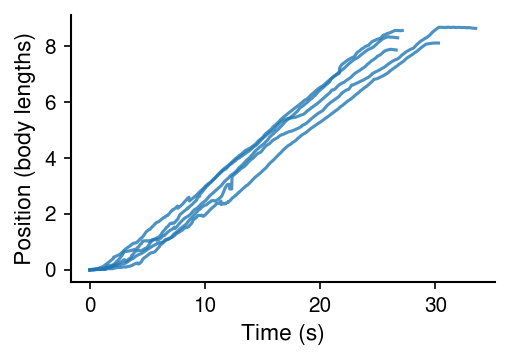


Per-trial speeds (body lengths/s):
  Trial 1: 0.2989 BL/s  (test 1_track.csv)
  Trial 2: 0.3509 BL/s  (test 2_track.csv)
  Trial 3: 0.3129 BL/s  (test 3_track.csv)
  Trial 4: 0.3569 BL/s  (test 4_track.csv)
  Trial 5: 0.3046 BL/s  (test 5_track.csv)

Average speed across trials: 0.3248 BL/s
Std across trials:           0.0271 BL/s
N = 5 trials


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# Publication-quality figure settings
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Nimbus Sans'],
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

def plot_bodylength_trials(folder_path, output_file=None):
    """
    Plot position (body lengths) vs time for multiple trials
    
    Args:
        folder_path: Path to folder containing *_track.csv files
        output_file: Optional path to save figure (e.g., 'figure.png')
    """
    
    folder = Path(folder_path)
    
    # Look for preferred names first: "test 1_track.csv" through "test 5_track.csv"
    files = []
    for i in range(1, 6):
        test_file = folder / f"test {i}_track.csv"
        if test_file.exists():
            files.append(test_file)
    
    # Fallback: grab any "*_track.csv" files
    if len(files) < 5:
        all_tracks = sorted(folder.glob("*_track.csv"))
        extra = [f for f in all_tracks if f not in files]
        files.extend(extra[:5 - len(files)])
    
    if not files:
        raise ValueError(f"No *_track.csv files found in {folder}")
    
    print(f"Using {len(files)} track file(s):")
    for f in files:
        print(f"  {f.name}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3.5, 2.5))  # Single-column width
    
    # Plot parameters
    color = '#1f77b4'
    linewidth = 1.5
    
    trial_speeds = []
    trial_names = []
    
    for i, file in enumerate(files):
        try:
            # Load data
            df = pd.read_csv(file)
            
            # Check for required columns
            if 't_sec' not in df.columns or 'position_body_lengths' not in df.columns:
                print(f"⚠️  Skipping {file.name}: missing required columns")
                continue
            
            # Extract and clean data
            t = df['t_sec'].values
            pos = df['position_body_lengths'].values
            
            # Remove NaN/inf values
            valid = np.isfinite(t) & np.isfinite(pos)
            t = t[valid]
            pos = pos[valid]
            
            if len(t) < 2:
                print(f"⚠️  Skipping {file.name}: not enough valid data points")
                continue
            
            # Sort by time
            sort_idx = np.argsort(t)
            t = t[sort_idx]
            pos = pos[sort_idx]
            
            # Plot
            ax.plot(t, pos, '-', color=color, linewidth=linewidth, alpha=0.8)
            
            # Calculate speed (BL/s) using linear fit
            slope, intercept, r_value, p_value, std_err = stats.linregress(t, pos)
            trial_speeds.append(slope)
            trial_names.append(file.name)
            
        except Exception as e:
            print(f"❌ Error loading {file.name}: {e}")
            continue
    
    # Format plot
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (body lengths)')
    # ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Save if requested
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to {output_file}")
    
    plt.show()
    
    # Print statistics
    if trial_speeds:
        trial_speeds = np.array(trial_speeds)
        avg_speed = np.mean(trial_speeds)
        std_speed = np.std(trial_speeds, ddof=1)  # Sample std
        
        print("\n" + "="*60)
        print("Per-trial speeds (body lengths/s):")
        for i, (speed, name) in enumerate(zip(trial_speeds, trial_names), 1):
            print(f"  Trial {i}: {speed:.4f} BL/s  ({name})")
        
        print(f"\nAverage speed across trials: {avg_speed:.4f} BL/s")
        print(f"Std across trials:           {std_speed:.4f} BL/s")
        print(f"N = {len(trial_speeds)} trials")
        print("="*60)
        
        return trial_speeds
    else:
        print("❌ No valid trials to compute speed")
        return None


# Usage example:
folder_path = "/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/turtle_speed_figure"
speeds = plot_bodylength_trials(folder_path, output_file="position_vs_time_overlay.png")

Using 5 track file(s):
  test 1_track.csv
  test 2_track.csv
  test 3_track.csv
  test 4_track.csv
  test 5_track.csv

✓ Loaded 5 valid trials
Time range: 0.00s to 33.49s

✓ Figure saved to position_mean_std.png


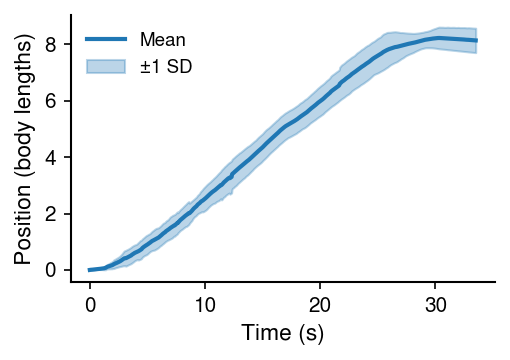


Per-trial speeds (body lengths/s):
  Trial 1: 0.2989 BL/s  (test 1_track.csv)
  Trial 2: 0.3509 BL/s  (test 2_track.csv)
  Trial 3: 0.3129 BL/s  (test 3_track.csv)
  Trial 4: 0.3569 BL/s  (test 4_track.csv)
  Trial 5: 0.3046 BL/s  (test 5_track.csv)

Average speed: 0.3248 ± 0.0271 BL/s
N = 5 trials


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.interpolate import interp1d

# Publication-quality figure settings
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Nimbus Sans'],
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

def plot_bodylength_mean_std(folder_path, output_file=None, n_points=1000):
    """
    Plot mean ± std of position (body lengths) vs time across trials
    
    Args:
        folder_path: Path to folder containing *_track.csv files
        output_file: Optional path to save figure
        n_points: Number of points for interpolated time grid
    """
    
    folder = Path(folder_path)
    
    # Find files (same logic as before)
    files = []
    for i in range(1, 6):
        test_file = folder / f"test {i}_track.csv"
        if test_file.exists():
            files.append(test_file)
    
    if len(files) < 5:
        all_tracks = sorted(folder.glob("*_track.csv"))
        extra = [f for f in all_tracks if f not in files]
        files.extend(extra[:5 - len(files)])
    
    if not files:
        raise ValueError(f"No *_track.csv files found in {folder}")
    
    print(f"Using {len(files)} track file(s):")
    for f in files:
        print(f"  {f.name}")
    
    # Load all trials and find common time range
    trial_data = []
    t_min_global = np.inf
    t_max_global = -np.inf
    
    for file in files:
        try:
            df = pd.read_csv(file)
            
            if 't_sec' not in df.columns or 'position_body_lengths' not in df.columns:
                print(f"⚠️  Skipping {file.name}: missing required columns")
                continue
            
            t = df['t_sec'].values
            pos = df['position_body_lengths'].values
            
            valid = np.isfinite(t) & np.isfinite(pos)
            t = t[valid]
            pos = pos[valid]
            
            if len(t) < 2:
                print(f"⚠️  Skipping {file.name}: not enough valid data points")
                continue
            
            sort_idx = np.argsort(t)
            t = t[sort_idx]
            pos = pos[sort_idx]
            
            trial_data.append({'t': t, 'pos': pos, 'name': file.name})
            
            t_min_global = min(t_min_global, t.min())
            t_max_global = max(t_max_global, t.max())
            
        except Exception as e:
            print(f"❌ Error loading {file.name}: {e}")
            continue
    
    if len(trial_data) < 2:
        print("❌ Need at least 2 valid trials to compute mean/std")
        return None
    
    print(f"\n✓ Loaded {len(trial_data)} valid trials")
    print(f"Time range: {t_min_global:.2f}s to {t_max_global:.2f}s")
    
    # Create common time grid
    t_common = np.linspace(t_min_global, t_max_global, n_points)
    
    # Interpolate each trial onto common time grid
    pos_interpolated = np.zeros((len(trial_data), n_points))
    
    for i, trial in enumerate(trial_data):
        # Linear interpolation
        interp_func = interp1d(trial['t'], trial['pos'], 
                               kind='linear', 
                               bounds_error=False, 
                               fill_value='extrapolate')
        pos_interpolated[i, :] = interp_func(t_common)
    
    # Compute mean and std across trials
    pos_mean = np.mean(pos_interpolated, axis=0)
    pos_std = np.std(pos_interpolated, axis=0, ddof=1)  # Sample std
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    # Plot mean line
    ax.plot(t_common, pos_mean, '-', color='#1f77b4', linewidth=2, label='Mean')
    
    # Plot shaded std region
    ax.fill_between(t_common, 
                     pos_mean - pos_std, 
                     pos_mean + pos_std,
                     color='#1f77b4', 
                     alpha=0.3, 
                     label='±1 SD')
    
    # Format plot
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (body lengths)')
    ax.legend(frameon=False, loc='best')
    # ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Save if requested
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to {output_file}")
    
    plt.show()
    
    # Calculate and report speeds
    trial_speeds = []
    for trial in trial_data:
        slope, _, _, _, _ = stats.linregress(trial['t'], trial['pos'])
        trial_speeds.append(slope)
    
    trial_speeds = np.array(trial_speeds)
    avg_speed = np.mean(trial_speeds)
    std_speed = np.std(trial_speeds, ddof=1)
    
    print("\n" + "="*60)
    print("Per-trial speeds (body lengths/s):")
    for i, (speed, trial) in enumerate(zip(trial_speeds, trial_data), 1):
        print(f"  Trial {i}: {speed:.4f} BL/s  ({trial['name']})")
    
    print(f"\nAverage speed: {avg_speed:.4f} ± {std_speed:.4f} BL/s")
    print(f"N = {len(trial_speeds)} trials")
    print("="*60)
    
    return {
        't_common': t_common,
        'pos_mean': pos_mean,
        'pos_std': pos_std,
        'speeds': trial_speeds,
        'avg_speed': avg_speed,
        'std_speed': std_speed
    }


# Usage:
folder_path = "/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/turtle_speed_figure"
results = plot_bodylength_mean_std(folder_path, output_file="position_mean_std.png")

### Turtle Diving

Using 5 track file(s):
  Trial 1: test1_track.csv (start time: 3.8s)
  Trial 2: test2_track.csv (start time: 8.8s)
  Trial 3: test3_track.csv (start time: 0.0s)
  Trial 4: test4_track.csv (start time: 2.6s)
  Trial 5: test5_track.csv (start time: 0.0s)

✓ Figure saved to depth_overlay.png


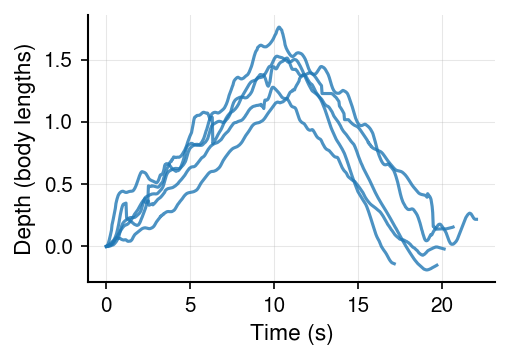


Per-trial speeds (body lengths/s):
  Trial 1: 0.1923 BL/s  (test1_track.csv)
  Trial 2: 0.1466 BL/s  (test2_track.csv)
  Trial 3: 0.2261 BL/s  (test3_track.csv)
  Trial 4: 0.1465 BL/s  (test4_track.csv)
  Trial 5: 0.2114 BL/s  (test5_track.csv)

Average speed across trials: 0.1846 BL/s
Std across trials:           0.0367 BL/s
N = 5 trials
Using 5 track file(s) for mean±std
✓ Loaded 5 valid trials
Common time range: 0.0s to 17.15s

✓ Figure saved to depth_mean_std.png


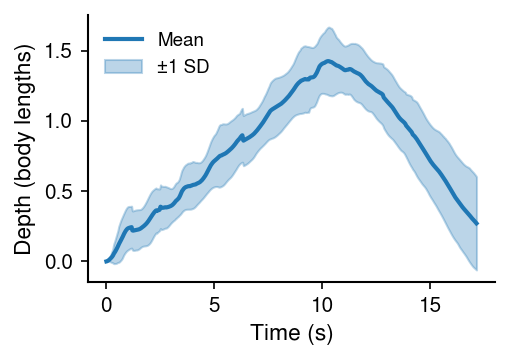


Average speed: 0.1846 ± 0.0367 BL/s
N = 5 trials


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

# Publication-quality figure settings
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Nimbus Sans'],
    'axes.linewidth': 1.0,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

def plot_depth_trials_overlay(folder_path, start_times=None, output_file=None):
    """
    Plot depth (body lengths) vs time for multiple trials - overlay version
    
    Args:
        folder_path: Path to folder containing *_track.csv files
        start_times: List/array of start times (s) for each trial [trial1, trial2, ...]
                     Use None or np.nan to use entire trial
        output_file: Optional path to save figure
    """
    
    folder = Path(folder_path)
    
    # Default start times if not provided
    if start_times is None:
        start_times = [3.8, 8.8, 0.0, 2.6, 0.0]  # From MATLAB code
    
    # Find files
    files = []
    for i in range(1, 6):
        test_file = folder / f"test {i}_track.csv"
        if test_file.exists():
            files.append(test_file)
    
    if len(files) < 5:
        all_tracks = sorted(folder.glob("*_track.csv"))
        extra = [f for f in all_tracks if f not in files]
        files.extend(extra[:5 - len(files)])
    
    if not files:
        raise ValueError(f"No *_track.csv files found in {folder}")
    
    print(f"Using {len(files)} track file(s):")
    for i, f in enumerate(files):
        start_t = start_times[i] if i < len(start_times) else 0.0
        print(f"  Trial {i+1}: {f.name} (start time: {start_t:.1f}s)")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    color = '#1f77b4'  # Dark gray
    linewidth = 1.5
    
    trial_speeds = []
    trial_names = []
    
    for i, file in enumerate(files):
        try:
            df = pd.read_csv(file)
            
            # Check for required columns
            if 't_sec' not in df.columns or 'down_body_lengths' not in df.columns:
                print(f"⚠️  Skipping {file.name}: missing required columns")
                continue
            
            t = df['t_sec'].values
            depth = df['down_body_lengths'].values
            
            # Clean data
            valid = np.isfinite(t) & np.isfinite(depth)
            t = t[valid]
            depth = depth[valid]
            
            if len(t) < 2:
                print(f"⚠️  Skipping {file.name}: not enough valid data points")
                continue
            
            # Sort by time
            sort_idx = np.argsort(t)
            t = t[sort_idx]
            depth = depth[sort_idx]
            
            # Apply start time cutoff
            if i < len(start_times) and not np.isnan(start_times[i]):
                keep = t >= start_times[i]
                t = t[keep]
                depth = depth[keep]
            
            if len(t) < 2:
                print(f"⚠️  Skipping {file.name}: not enough data after start time")
                continue
            
            # Apply offsets (reset origin)
            t0 = t[0]
            depth0 = depth[0]
            t = t - t0
            depth = depth - depth0
            
            # Plot
            ax.plot(t, depth, '-', color=color, linewidth=linewidth, alpha=0.8)
            
            # Calculate average speed (total path length / time)
            path_length = np.sum(np.abs(np.diff(depth)))  # BL
            total_time = t[-1] - t[0]  # seconds
            
            if total_time <= 0:
                print(f"⚠️  Skipping {file.name}: non-positive duration")
                continue
            
            avg_speed = path_length / total_time  # BL/s
            trial_speeds.append(avg_speed)
            trial_names.append(file.name)
            
        except Exception as e:
            print(f"❌ Error loading {file.name}: {e}")
            continue
    
    # Format plot
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Depth (body lengths)')
    # ax.set_title(f'Depth vs Time (N={len(trial_speeds)})')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Invert y-axis so depth increases downward (optional, comment out if not desired)
    # ax.invert_yaxis()
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to {output_file}")
    
    plt.show()
    
    # Print statistics
    if trial_speeds:
        trial_speeds = np.array(trial_speeds)
        avg_speed = np.mean(trial_speeds)
        std_speed = np.std(trial_speeds, ddof=1)
        
        print("\n" + "="*60)
        print("Per-trial speeds (body lengths/s):")
        for i, (speed, name) in enumerate(zip(trial_speeds, trial_names), 1):
            print(f"  Trial {i}: {speed:.4f} BL/s  ({name})")
        
        print(f"\nAverage speed across trials: {avg_speed:.4f} BL/s")
        print(f"Std across trials:           {std_speed:.4f} BL/s")
        print(f"N = {len(trial_speeds)} trials")
        print("="*60)
        
        return trial_speeds
    else:
        print("❌ No valid trials to compute speed")
        return None


def plot_depth_trials_mean_std(folder_path, start_times=None, output_file=None, n_points=1000):
    """
    Plot mean ± std of depth (body lengths) vs time across trials
    
    Args:
        folder_path: Path to folder containing *_track.csv files
        start_times: List/array of start times (s) for each trial
        output_file: Optional path to save figure
        n_points: Number of points for interpolated time grid
    """
    
    folder = Path(folder_path)
    
    if start_times is None:
        start_times = [3.8, 8.8, 0.0, 2.6, 0.0]
    
    # Find files
    files = []
    for i in range(1, 6):
        test_file = folder / f"test {i}_track.csv"
        if test_file.exists():
            files.append(test_file)
    
    if len(files) < 5:
        all_tracks = sorted(folder.glob("*_track.csv"))
        extra = [f for f in all_tracks if f not in files]
        files.extend(extra[:5 - len(files)])
    
    if not files:
        raise ValueError(f"No *_track.csv files found in {folder}")
    
    print(f"Using {len(files)} track file(s) for mean±std")
    
    # Load all trials
    trial_data = []
    t_max_common = np.inf  # Find minimum max time across trials
    
    for i, file in enumerate(files):
        try:
            df = pd.read_csv(file)
            
            if 't_sec' not in df.columns or 'down_body_lengths' not in df.columns:
                continue
            
            t = df['t_sec'].values
            depth = df['down_body_lengths'].values
            
            valid = np.isfinite(t) & np.isfinite(depth)
            t = t[valid]
            depth = depth[valid]
            
            if len(t) < 2:
                continue
            
            sort_idx = np.argsort(t)
            t = t[sort_idx]
            depth = depth[sort_idx]
            
            # Apply start time
            if i < len(start_times) and not np.isnan(start_times[i]):
                keep = t >= start_times[i]
                t = t[keep]
                depth = depth[keep]
            
            if len(t) < 2:
                continue
            
            # Apply offsets
            t0 = t[0]
            depth0 = depth[0]
            t = t - t0
            depth = depth - depth0
            
            trial_data.append({'t': t, 'depth': depth, 'name': file.name})
            t_max_common = min(t_max_common, t.max())
            
        except Exception as e:
            print(f"❌ Error loading {file.name}: {e}")
            continue
    
    if len(trial_data) < 2:
        print("❌ Need at least 2 valid trials to compute mean/std")
        return None
    
    print(f"✓ Loaded {len(trial_data)} valid trials")
    print(f"Common time range: 0.0s to {t_max_common:.2f}s")
    
    # Create common time grid (use minimum of max times)
    t_common = np.linspace(0, t_max_common, n_points)
    
    # Interpolate each trial
    depth_interpolated = np.zeros((len(trial_data), n_points))
    
    for i, trial in enumerate(trial_data):
        interp_func = interp1d(trial['t'], trial['depth'], 
                               kind='linear', 
                               bounds_error=False, 
                               fill_value='extrapolate')
        depth_interpolated[i, :] = interp_func(t_common)
    
    # Compute mean and std
    depth_mean = np.mean(depth_interpolated, axis=0)
    depth_std = np.std(depth_interpolated, axis=0, ddof=1)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    # Plot mean and std
    ax.plot(t_common, depth_mean, '-', color='#1f77b4', linewidth=2, label='Mean')
    ax.fill_between(t_common, 
                     depth_mean - depth_std, 
                     depth_mean + depth_std,
                     color='#1f77b4', alpha=0.3, label='±1 SD')
    
    # Format plot
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Depth (body lengths)')
    # ax.set_title(f'Depth vs Time (N={len(trial_data)})')
    ax.legend(frameon=False, loc='best')
    # ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Optional: invert y-axis
    # ax.invert_yaxis()
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to {output_file}")
    
    plt.show()
    
    # Calculate speeds
    trial_speeds = []
    for trial in trial_data:
        path_length = np.sum(np.abs(np.diff(trial['depth'])))
        total_time = trial['t'][-1] - trial['t'][0]
        if total_time > 0:
            trial_speeds.append(path_length / total_time)
    
    trial_speeds = np.array(trial_speeds)
    avg_speed = np.mean(trial_speeds)
    std_speed = np.std(trial_speeds, ddof=1)
    
    print("\n" + "="*60)
    print(f"Average speed: {avg_speed:.4f} ± {std_speed:.4f} BL/s")
    print(f"N = {len(trial_speeds)} trials")
    print("="*60)
    
    return {
        't_common': t_common,
        'depth_mean': depth_mean,
        'depth_std': depth_std,
        'speeds': trial_speeds,
        'avg_speed': avg_speed,
        'std_speed': std_speed
    }


# Usage examples:

# 1. Overlay plot with custom start times
folder_path = "/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/diving_figure"
start_times = [3.8, 8.8, 0.0, 2.6, 0.0]  # Match MATLAB code

speeds = plot_depth_trials_overlay(
    folder_path, 
    start_times=start_times,
    output_file="depth_overlay.png"
)

# 2. Mean ± std plot
results = plot_depth_trials_mean_std(
    folder_path,
    start_times=start_times,
    output_file="depth_mean_std.png"
)

### Obstacle Avoidance and Depth Tracking

In [19]:
frame_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/stitched'
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/timestamps_C.txt'
npz_file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/tetherless_trial_C_data_sept_30_11_pm.npz'
matched_timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/depth'  
detection_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/detection'
data = np.genfromtxt(matched_timestamps_file, delimiter=',', skip_header=1)
timestamps_unix = data
t_quat_heading = timestamps_unix - timestamps_unix[0]
plot_dir = os.path.join(os.path.dirname(npz_file_path), "plots")


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from polish_matplotlib import polish_matplotlib

plt.style.use('default')
plt.rcParams['font.family'] = 'Nimbus Sans'

# Color scheme
color_actual = '#23334a'
color_desired = '#ff9955ff'
color_threshold = '#ff9955ff'
color_turn_left = '#1f77b4'
color_turn_right = '#FFD93D'

# Load data
depth_data = npz_file['depth']
depth_d_data = np.ones(depth_data.shape) * 1.1

# # for trial A:
# depth_d_data[5513:] = 0
stereo_depth_data = npz_file['stereo_debug_depth']
turn_commands = npz_file['turn_commands']
headings = npz_file['headings']
yaw_d = npz_file['yaw_d'][1:]

# Load time arrays
t_sensor_node = npz_file['t_sensor_node']
# t_quat_heading = npz_file['t_quat_heading']

print(f"Duration: {t_sensor_node[-1]:.1f}s")
print(f"Timestamp for frame 21: {t_quat_heading[21]}")
print(f"Depth data: {len(depth_data)} samples")
print(f"Stereo data: {len(stereo_depth_data)} samples")
print(f"Heading data: {len(headings)} samples")

# Define time window
############# TRIAL C #############
time_start = 6.21
time_limit = time_start + 341
# time_start = 6.2
# time_limit = 500 # TRIAL C
# time_limit = 138  # TRIAL A
# time_limit = 120  # TRIAL B

# ============================================================================
# PANEL 1: Filter depth tracking data
# ============================================================================
# mask_depth = t_sensor_node <= time_limit
# t_depth = t_sensor_node[mask_depth]
# depth_filtered = depth_data[mask_depth]
# depth_d_filtered = depth_d_data[mask_depth]

mask_depth = (t_sensor_node >= time_start) & (t_sensor_node <= time_limit)
t_depth = t_sensor_node[mask_depth]
depth_filtered = depth_data[mask_depth]
depth_d_filtered = depth_d_data[mask_depth]


depth_error = depth_filtered - depth_d_filtered
rmse_depth = np.sqrt(np.mean(np.square(depth_error)))
mae_depth = np.mean(np.abs(depth_error))

# ============================================================================
# PANEL 2: Filter stereo/obstacle data
# ============================================================================
stereo_length = min(len(stereo_depth_data), len(t_quat_heading), len(turn_commands))
t_stereo = t_quat_heading[:stereo_length]
stereo_filtered = stereo_depth_data[:stereo_length]
turn_filtered = turn_commands[:stereo_length]

# mask_stereo = t_stereo <= time_limit
mask_stereo = (t_stereo >= time_start) & (t_stereo <= time_limit)
t_stereo = t_stereo[mask_stereo]
stereo_filtered = stereo_filtered[mask_stereo]
turn_filtered = turn_filtered[mask_stereo]

valid_mask = stereo_filtered > 0.1
t_stereo_valid = t_stereo[valid_mask]
stereo_valid = stereo_filtered[valid_mask]

# ============================================================================
# PANEL 3: Filter heading data
# ============================================================================
heading_length = min(len(headings), len(yaw_d), len(t_quat_heading))
print(f"len of headins: {len(headings)}")
print(f"len of yaw d: {len(yaw_d)}")
print(f"len of t quat heading: {len(t_quat_heading)}")
print(f"heading length: {heading_length}")
t_heading = t_quat_heading[:heading_length]
headings_raw = headings[:heading_length]
yaw_d_raw = yaw_d[:heading_length]

# mask_heading = t_heading <= time_limit
mask_heading = (t_heading >= time_start) & (t_heading <= time_limit)
print(f"mask heading: {mask_heading[:-10]}")
t_heading = t_heading[mask_heading]
headings_raw = headings_raw[mask_heading]
yaw_d_raw = yaw_d_raw[mask_heading]

# Unwrap and convert to degrees
headings_unwrapped = np.unwrap(headings_raw)
yaw_d_unwrapped = np.unwrap(yaw_d_raw)
headings_deg = np.degrees(headings_unwrapped)
yaw_d_deg = np.degrees(yaw_d_unwrapped)

# Make relative (start at zero)
headings_relative = headings_deg - headings_deg[0]
yaw_d_relative = yaw_d_deg - yaw_d_deg[0]

# Calculate heading error
heading_error = headings_deg - yaw_d_deg
rmse_heading = np.sqrt(np.mean(np.square(heading_error)))
mae_heading = np.mean(np.abs(heading_error))
print(f"\nHeading panel: {t_heading[0]:.2f}s - {t_heading[-1]:.2f}s ({len(t_heading)} samples)")
print(f"Total Selected Duration: {t_heading[-1] - t_heading[0]}\n")
print(f"Total rotation: {headings_relative[-1]:.1f}°")

# Common x-axis limits
# x_min = 0
# x_max = time_limit
x_min = time_start
x_max = time_limit
# ============================================================================
# Create figure with 3 vertically stacked subplots
# ============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

# ============================================================================
# TOP PANEL: Depth Tracking
# ============================================================================
ax1.plot(t_depth, depth_filtered, '-', color=color_actual, 
         label='Actual Depth', linewidth=2, alpha=1.0, zorder=3)
ax1.plot(t_depth, depth_d_filtered, '--', color=color_desired, 
         label='Desired Depth', linewidth=2, alpha=1.0, zorder=2)
ax1.fill_between(t_depth, depth_filtered, depth_d_filtered,
                 alpha=0.2, color=color_actual, zorder=1)

ax1.set_ylabel('Depth (m)')
ax1.set_xlim(x_min, x_max)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.locator_params(axis='y', nbins=4)

error_text = f"RMSE: {rmse_depth:.3f} m\nMAE: {mae_depth:.3f} m"
ax1.text(0.015, 0.95, error_text, transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))

# ============================================================================
# MIDDLE PANEL: Obstacle Avoidance
# ============================================================================
# Highlight turn regions
in_turn = False
turn_start = None
turn_type = None
left_labeled = False
right_labeled = False
threshold = 3.0

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled else '', zorder=1)
            left_labeled = True
        elif turn_type == "turn right":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled else '', zorder=1)
            right_labeled = True
        
        in_turn = False
        turn_type = None

if in_turn:
    if turn_type == "turn left":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled else '', zorder=1)
    elif turn_type == "turn right":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled else '', zorder=1)

ax2.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
            label='Avoidance Threshold', zorder=2, alpha=1.0)
ax2.plot(t_stereo_valid, stereo_valid, linewidth=2, color=color_actual, 
         zorder=3, alpha=1.0, label='Measured Distance')

ax2.set_ylabel('Obstacle Distance (m)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 10)
ax2.legend(loc='upper right', framealpha=0.9)
ax2.locator_params(axis='y', nbins=4)

# ============================================================================
# BOTTOM PANEL: Heading Control
# ============================================================================
# Also add turn region highlighting to heading panel
in_turn = False
turn_start = None
turn_type = None
left_labeled_h = False
right_labeled_h = False

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        # Get y-limits for shading
        y_min_h = min(np.min(headings_relative), np.min(yaw_d_relative)) - 20
        y_max_h = max(np.max(headings_relative), np.max(yaw_d_relative)) + 20
        
        if turn_type == "turn left":
            ax3.fill_between([turn_start, turn_end], y_min_h, y_max_h, alpha=0.15, 
                            color=color_turn_left, zorder=1)
        elif turn_type == "turn right":
            ax3.fill_between([turn_start, turn_end], y_min_h, y_max_h, alpha=0.15, 
                            color=color_turn_right, zorder=1)
        
        in_turn = False
        turn_type = None

if in_turn:
    y_min_h = min(np.min(headings_relative), np.min(yaw_d_relative)) - 20
    y_max_h = max(np.max(headings_relative), np.max(yaw_d_relative)) + 20
    
    if turn_type == "turn left":
        ax3.fill_between([turn_start, t_stereo[-1]], y_min_h, y_max_h, alpha=0.15, 
                        color=color_turn_left, zorder=1)
    elif turn_type == "turn right":
        ax3.fill_between([turn_start, t_stereo[-1]], y_min_h, y_max_h, alpha=0.15, 
                        color=color_turn_right, zorder=1)

# Plot heading data
ax3.plot(t_heading, headings_relative, '-', color=color_actual, 
         label='Actual Heading', linewidth=2, alpha=1.0, zorder=3)
ax3.plot(t_heading, yaw_d_relative, '--', color=color_desired, 
         label='Desired Heading', linewidth=2, alpha=1.0, zorder=2)
ax3.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)

ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Heading Change (°)')
ax3.set_xlim(x_min, x_max)
ax3.legend(loc='upper left', framealpha=0.9)
ax3.locator_params(axis='y', nbins=4)

error_text_h = f"RMSE: {rmse_heading:.1f}°\nMAE: {mae_heading:.1f}°"
ax3.text(0.86, 0.8, error_text_h, transform=ax3.transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))

# ============================================================================
# Apply polish_matplotlib
# ============================================================================
polish_matplotlib(fig, [ax1, ax2, ax3],
                  base_fontsize=12,
                  label_fontsize=14,
                  line_width=2,
                  marker_size=8,
                  fig_size_inches=(10, 8),
                  use_tex=False,
                  grid=False,
                  box_on=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)

# Save the combined plot
save_path = os.path.join(plot_dir, "complete_trial_analysis.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"\n✅ Saved complete trial analysis to {save_path}")

print(f"\nPerformance Metrics:")
print(f"  Depth   - RMSE: {rmse_depth:.4f} m | MAE: {mae_depth:.4f} m")
print(f"  Heading - RMSE: {rmse_heading:.1f}° | MAE: {mae_heading:.1f}°")
print(f"  Total rotation: {headings_relative[-1]:.1f}°")

plt.show()
plt.close(fig)

Duration: 426.3s
Timestamp for frame 21: 2.009032
Depth data: 21713 samples
Stereo data: 8422 samples
Heading data: 8422 samples
len of headins: 8422
len of yaw d: 8422
len of t quat heading: 8422
heading length: 8422
mask heading: [False False False ... False False False]

Heading panel: 6.27s - 347.21s (6820 samples)
Total Selected Duration: 340.939751

Total rotation: -768.1°

✅ Saved complete trial analysis to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/complete_trial_analysis.png

Performance Metrics:
  Depth   - RMSE: 0.1952 m | MAE: 0.1340 m
  Heading - RMSE: 370.9° | MAE: 323.0°
  Total rotation: -768.1°


### IMU data

In [22]:
# Create supplementary IMU figure
fig_imu, (ax_orient, ax_gyro, ax_acc) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Load IMU data
quat_data = npz_file['quat']  # (n, 4) - [w, x, y, z]
acc_data = npz_file['acc']     # (n, 3) - [x, y, z] in m/s²
gyr_data = npz_file['gyr']     # (n, 3) - [x, y, z] in deg/s
t_imu = t_sensor_node[:len(quat_data)]  # Assuming same timing as depth

# Filter to time window
mask_imu = (t_imu >= time_start) & (t_imu <= time_limit)
t_imu_filtered = t_imu[mask_imu]
quat_filtered = quat_data[mask_imu]
acc_filtered = acc_data[mask_imu]
gyr_filtered = gyr_data[mask_imu]

# ============================================================================
# PANEL 1: Orientation (Roll & Pitch from quaternions)
# ============================================================================
def quat_to_euler(quat):
    """Convert quaternion [w, x, y, z] to roll, pitch, yaw in degrees"""
    w, x, y, z = quat[:, 0], quat[:, 1], quat[:, 2], quat[:, 3]
    
    # Roll (x-axis rotation)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)
    
    # Pitch (y-axis rotation)
    sinp = 2 * (w * y - z * x)
    pitch = np.arcsin(np.clip(sinp, -1.0, 1.0))
    
    # Yaw (z-axis rotation)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    
    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)

roll, pitch, yaw = quat_to_euler(quat_filtered)

ax_orient.plot(t_imu_filtered, roll, label='Roll', linewidth=2, color='#E63946', alpha=0.9)
ax_orient.plot(t_imu_filtered, pitch, label='Pitch', linewidth=2, color='#F18F01', alpha=0.9)
ax_orient.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_orient.set_ylabel('Angle (°)')
ax_orient.set_title('Robot Orientation')
ax_orient.legend(loc='upper right', framealpha=0.9)
ax_orient.set_xlim(x_min, x_max)

# Add turn regions
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    elif in_turn and cmd not in ["turn left", "turn right"]:
        y_min = min(np.min(roll), np.min(pitch)) - 5
        y_max = max(np.max(roll), np.max(pitch)) + 5
        color = color_turn_left if turn_type == "turn left" else color_turn_right
        ax_orient.fill_between([turn_start, t_stereo[i]], y_min, y_max, 
                               alpha=0.15, color=color, zorder=1)
        in_turn = False

# Add surface commands
# for surf_time in surface_times:
#     if x_min <= surf_time <= x_max:
#         ax_orient.axvline(x=surf_time, color=color_surface, linestyle=':', 
#                          linewidth=2.5, alpha=0.8, zorder=5)

# ============================================================================
# PANEL 2: Angular Velocity (Gyroscope)
# ============================================================================
ax_gyro.plot(t_imu_filtered, gyr_filtered[:, 0], label='Gyro X (Roll rate)', 
             linewidth=1.5, color='#E63946', alpha=0.8)
ax_gyro.plot(t_imu_filtered, gyr_filtered[:, 1], label='Gyro Y (Pitch rate)', 
             linewidth=1.5, color='#F18F01', alpha=0.8)
ax_gyro.plot(t_imu_filtered, gyr_filtered[:, 2], label='Gyro Z (Yaw rate)', 
             linewidth=2, color='#457B9D', alpha=0.9)
ax_gyro.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_gyro.set_ylabel('Angular Velocity (°/s)')
ax_gyro.legend(loc='upper right', framealpha=0.9)
ax_gyro.set_xlim(x_min, x_max)

# Add turn regions and surface commands (same as above)
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    elif in_turn and cmd not in ["turn left", "turn right"]:
        y_min = np.min(gyr_filtered) - 5
        y_max = np.max(gyr_filtered) + 5
        color = color_turn_left if turn_type == "turn left" else color_turn_right
        ax_gyro.fill_between([turn_start, t_stereo[i]], y_min, y_max, 
                             alpha=0.15, color=color, zorder=1)
        in_turn = False

# for surf_time in surface_times:
#     if x_min <= surf_time <= x_max:
#         ax_gyro.axvline(x=surf_time, color=color_surface, linestyle=':', 
#                        linewidth=2.5, alpha=0.8, zorder=5)

# ============================================================================
# PANEL 3: Linear Acceleration
# ============================================================================
ax_acc.plot(t_imu_filtered, acc_filtered[:, 0], label='Acc X (Forward)', 
            linewidth=1.5, color='#2E86AB', alpha=0.8)
ax_acc.plot(t_imu_filtered, acc_filtered[:, 1], label='Acc Y (Lateral)', 
            linewidth=1.5, color='#A23B72', alpha=0.8)
ax_acc.plot(t_imu_filtered, acc_filtered[:, 2], label='Acc Z (Vertical)', 
            linewidth=1.5, color='#06A77D', alpha=0.8)
ax_acc.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, 
               label='1g (gravity)')
ax_acc.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_acc.set_ylabel('Acceleration (m/s²)')
ax_acc.set_xlabel('Time (s)')
ax_acc.legend(loc='upper right', framealpha=0.9)
ax_acc.set_xlim(x_min, x_max)

# Add turn regions and surface commands (same as above)
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    elif in_turn and cmd not in ["turn left", "turn right"]:
        y_min = np.min(acc_filtered) - 0.2
        y_max = np.max(acc_filtered) + 0.2
        color = color_turn_left if turn_type == "turn left" else color_turn_right
        ax_acc.fill_between([turn_start, t_stereo[i]], y_min, y_max, 
                            alpha=0.15, color=color, zorder=1)
        in_turn = False

# for surf_time in surface_times:
#     if x_min <= surf_time <= x_max:
#         ax_acc.axvline(x=surf_time, color=color_surface, linestyle=':', 
#                       linewidth=2.5, alpha=0.8, zorder=5)

# Polish and save
polish_matplotlib(fig_imu, [ax_orient, ax_gyro, ax_acc],
                  base_fontsize=12,
                  label_fontsize=14,
                  line_width=2,
                  marker_size=8,
                  fig_size_inches=(10, 8),
                  use_tex=False,
                  grid=False,
                  box_on=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)
save_path_imu = os.path.join(plot_dir, "imu_supplementary.png")
plt.savefig(save_path_imu, dpi=600, bbox_inches='tight', facecolor='white')
print(f"✅ Saved IMU supplementary figure to {save_path_imu}")
plt.show()

✅ Saved IMU supplementary figure to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/imu_supplementary.png


### VIDEO GENERATION with time syncing

In [45]:
frame_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/stitched'
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/timestamps_C.txt'
npz_file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/tetherless_trial_C_data_sept_30_11_pm.npz'
matched_timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)

depth_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/depth'  
detection_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/detection'
file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C//'

In [47]:
frame_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_03_38_tetherless_B/stitched'
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_03_38_tetherless_B/timestamps_B.txt'
npz_file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/logger_converted.npz'
matched_timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_03_38_tetherless_B/depth'
detection_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_03_38_tetherless_B/detection'
file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030830_tetherless_B/'

In [57]:

frame_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_14_48_26_tetherless_A/stitched'
timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_14_48_26_tetherless_A/timestamps_A.txt'
npz_file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/logger_converted.npz'
matched_timestamps_file = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_14_48_26_tetherless_A/depth'
detection_frames_dir = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_14_48_26_tetherless_A/detection'
file_path = '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/'

Exception ignored in: <function Variable.__del__ at 0x713ed3f66ca0>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 414, in __del__
    if self._tk.getboolean(self._tk.call("info", "exists", self._name)):
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: main thread is not in main loop


In [21]:
video_dir = '/home/ranger/tortuga_jan_data/video/01_30_2026_11_07_46_OA_trial_1/'
frame_dir = video_dir + 'stitched'
timestamps_file = video_dir + 'left/timestamps.txt'
npz_file_path = '/home/ranger/tortuga_jan_data/logs/20260130_110740_OA_trial_1/logger_converted.npz'
matched_timestamps_file = '/home/ranger/tortuga_jan_data/logs/20260130_110740_OA_trial_1/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = video_dir + 'depth'
detection_frames_dir = video_dir  + '/detection'
file_path = video_dir

In [24]:
video_dir = '/home/ranger/tortuga_jan_data/video/01_30_2026_11_13_45_OA_trial_2/'
frame_dir = video_dir + 'stitched'
timestamps_file = video_dir + 'left/timestamps.txt'
npz_file_path = '/home/ranger/tortuga_jan_data/logs/20260130_111339_OA_trial_2/logger_converted.npz'
matched_timestamps_file = '/home/ranger/tortuga_jan_data/logs/20260130_111339_OA_trial_2/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = video_dir + 'depth'
detection_frames_dir = video_dir  + '/detection'
file_path = video_dir

In [27]:
video_dir = '/home/ranger/tortuga_jan_data/video/01_30_2026_11_25_34_OA_trial_3/'
frame_dir = video_dir + 'stitched'
timestamps_file = video_dir + 'left/timestamps.txt'
npz_file_path = '/home/ranger/tortuga_jan_data/logs/20260130_112527_OA_trial_3/logger_converted.npz'
matched_timestamps_file = '/home/ranger/tortuga_jan_data/logs/20260130_112527_OA_trial_3/matched_timestamps_temporal.txt'
npz_file = np.load(npz_file_path, allow_pickle=True)
depth_frames_dir = video_dir + 'depth'
detection_frames_dir = video_dir  + '/detection'
file_path = video_dir

In [4]:
npz_file = np.load(npz_file_path, allow_pickle=True)
keys = list(npz_file.keys())
print(f"Keys found: {keys}")
for key in keys:
    print(f"{key} has shape: {npz_file[key].shape}")

depth_data = npz_file['depth']
t_sensor_node = npz_file['t_sensor_node']
print(f"end time: {t_sensor_node[-1]}")

entry_idx, entry_time = detect_water_entry(
    depth_data, 
    t_sensor_node, 
    depth_threshold=0.1,  # Robot must be >10cm deep
    window_size=5          # Must stay deep for 5 readings
)

if entry_time is None:
    print("⚠️  WARNING: Could not detect water entry!")
    print("   Using full recording duration")
    entry_time = t_sensor_node[0]
    entry_idx = 0
else:
    print(f"✅ Water entry detected at t={entry_time:.2f}s aka index {entry_idx}")
    print(f"   Pre-water time: {entry_time - t_sensor_node[0]:.2f}s (robot on deck)")

print(f"Total OA time: {t_sensor_node[-1] - entry_time}")
print(np.unique(npz_file['depth']))
print(npz_file['turn_commands'][0:500])

Keys found: ['q', 'dq', 't_sensor_node', 't_logger_node', 'u', 'nav_u', 'qd', 'dqd', 'depth', 'depth_d', 'quat', 'alt', 'yaw_d', 'stereo_depth', 'stereo_debug_depth', 'stereo_point', 'acc', 'gyr', 'voltage', 'fps', 'headings', 'turn_commands']
q has shape: (16674, 10)
dq has shape: (16674, 10)
t_sensor_node has shape: (16674,)
t_logger_node has shape: (16674,)
u has shape: (5582, 10)
nav_u has shape: (5746, 4)
qd has shape: (16674, 10)
dqd has shape: (16674, 10)
depth has shape: (16674,)
depth_d has shape: (16674,)
quat has shape: (16674, 4)
alt has shape: (16674,)
yaw_d has shape: (5747,)
stereo_depth has shape: (16674,)
stereo_debug_depth has shape: (5719,)
stereo_point has shape: (2, 16674)
acc has shape: (16674, 3)
gyr has shape: (16674, 3)
voltage has shape: (16674,)
fps has shape: (1410,)
headings has shape: (5719,)
turn_commands has shape: (5719,)
end time: 288.3841438293457
⚠️  WARNING: Could not detect water entry!
   Using full recording duration
Total OA time: 288.3841438293

In [22]:
import numpy as np
import matplotlib.pyplot as plt

npz_file = np.load(npz_file_path, allow_pickle=True)
depth_data = npz_file['depth']

print(f"Shape: {depth_data.shape}")
print(f"Range: [{np.min(depth_data):.2f}, {np.max(depth_data):.2f}]")

# Auto-plot based on shape
plt.figure(figsize=(12, 6))
if depth_data.ndim == 1:
    plt.plot(depth_data)
elif depth_data.ndim == 2:
    plt.imshow(depth_data, cmap='viridis', aspect='auto')
    plt.colorbar()
else:
    plt.imshow(depth_data[0], cmap='viridis')  # Show first frame
    plt.colorbar()
    plt.title(f'Frame 0 of {depth_data.shape[0]}')
plt.ylim([-0.75, 0.2])  # Or use a fixed range like: plt.ylim([-10, 1])
plt.show()
npz_file.close()
print(depth_data[0:50])

Shape: (16674,)
Range: [-417.29, 0.10]
[-0.41 -0.41 -0.41 -0.45 -0.45 -0.45 -0.45 -0.45 -0.45 -0.42 -0.42 -0.42
 -0.42 -0.42 -0.42 -0.42 -0.42 -0.43 -0.43 -0.43 -0.43 -0.43 -0.43 -0.43
 -0.43 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41
 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41 -0.41
 -0.41 -0.39]


## Complete Trial Analysis Corrected -- For Figures

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from polish_matplotlib import polish_matplotlib

# grab t_quat timestamps
data = np.genfromtxt(matched_timestamps_file, delimiter=',', skip_header=1)
first_valid_idx = np.where(~np.isnan(data))[0][0]
timestamps_unix = data[first_valid_idx:]
t_quat_heading = timestamps_unix - timestamps_unix[0]

# print(f"t_quat heading:{t_quat_heading}")
npz_file = np.load(npz_file_path, allow_pickle=True)
keys = list(npz_file.keys())
# Create a directory to save plots
plot_dir = os.path.join(os.path.dirname(file_path), "plots")
os.makedirs(plot_dir, exist_ok=True)


plt.style.use('default')
plt.rcParams['font.family'] = 'Nimbus Sans'

# Color scheme
color_actual = '#23334a'
color_desired = '#ff9955ff'
color_threshold = '#ff9955ff'
color_turn_left = '#1f77b4'
color_turn_right = '#FFD93D'

# Load data
depth_data = npz_file['depth']
# print(f"depth data: {depth_data[0:500]}")
depth_d_data = np.ones(depth_data.shape) * 1.1
# stereo_depth_data = npz_file['stereo_debug_depth']
# turn_commands = npz_file['turn_commands']
# headings = npz_file['headings']
# yaw_d = npz_file['yaw_d'][1:]
stereo_depth_data = npz_file['stereo_debug_depth'][first_valid_idx:]
turn_commands = npz_file['turn_commands'][first_valid_idx:]
# print(f"turn commands[0:500]: {turn_commands[0:500]}")
headings = npz_file['headings'][first_valid_idx:]
yaw_d = npz_file['yaw_d'][1:][first_valid_idx:]  # Already has [1:], then trim NaNs
# print(f"headings shape: {headings.shape}")
# Load time arrays
t_sensor_node = npz_file['t_sensor_node']

print(f"Duration: {t_sensor_node[-1]:.1f}s")
print(f"Depth data: {len(depth_data)} samples")
print(f"Stereo data: {len(stereo_depth_data)} samples")
print(f"first few: {stereo_depth_data[0:20]}")
print(f"Heading data: {len(headings)} samples")
print(f"heading index 0: {headings[0]}")
# Define time window

##### TRIAL C window #####
# time_start = 6.2               
# time_limit = time_start + 341 
# time_start = 0.0
# time_limit = 426.3
##### TRIAL B window #####
# time_start = 6.03
# time_limit = 100.375 

##### TRIAL A window #####
time_start = 4.86
time_limit = 137

##### TRIAL 1 OA window #####
# time_start = 0
# time_start = 10     # frame when turtle enters water
# time_limit = 270

# time_limit = 286
##### TRIAL 2 OA window #####
# time_start = 0
# time_limit = 397
##### TRIAL 3 OA window #####
# time_start = 0
# time_limit = 560

print(f"============== Total Duration: {time_limit - time_start}================\n")
# ============================================================================
# PANEL 1: Filter depth tracking data
# ============================================================================
mask_depth = (t_sensor_node >= time_start) & (t_sensor_node <= time_limit)
t_depth = t_sensor_node[mask_depth]
depth_filtered = depth_data[mask_depth]
depth_d_filtered = depth_d_data[mask_depth]

depth_error = depth_filtered - depth_d_filtered
rmse_depth = np.sqrt(np.mean(np.square(depth_error)))
mae_depth = np.mean(np.abs(depth_error))

# ============================================================================
# PANEL 2: Filter stereo/obstacle data
# ============================================================================
stereo_length = min(len(stereo_depth_data), len(t_quat_heading), len(turn_commands))
t_stereo = t_quat_heading[:stereo_length]
stereo_filtered = stereo_depth_data[:stereo_length]
turn_filtered = turn_commands[:stereo_length]

mask_stereo = (t_stereo >= time_start) & (t_stereo <= time_limit)
t_stereo = t_stereo[mask_stereo]
stereo_filtered = stereo_filtered[mask_stereo]
turn_filtered = turn_filtered[mask_stereo]

valid_mask = stereo_filtered > 0.1
t_stereo_valid = t_stereo[valid_mask]
stereo_valid = stereo_filtered[valid_mask]
# print(f"turn filtered: {turn_filtered[0:500]}")
# ============================================================================
# PANEL 3: Filter heading data WITH PROPER UNWRAPPING
# ============================================================================
heading_length = min(len(headings), len(yaw_d), len(t_quat_heading))
# print(f"heading length: {heading_length}")
t_heading = t_quat_heading[:heading_length]
headings_raw = headings[:heading_length]
# print(f"headings raw shape: {headings_raw.shape}")
yaw_d_raw = yaw_d[:heading_length]
# print(f"t heading: {t_heading}")
mask_heading = (t_heading >= time_start) & (t_heading <= time_limit)
# print(f"mash heading: {mask_heading}")
t_heading = t_heading[mask_heading]
headings_raw = headings_raw[mask_heading]
yaw_d_raw = yaw_d_raw[mask_heading]
# print(f"headingsn raw shape{headings_raw}")
# Unwrap actual heading
headings_unwrapped = np.unwrap(headings_raw)
headings_deg = np.degrees(headings_unwrapped)
# print(f"headings def shape: {headings_deg.shape}")
# PROPERLY unwrap yaw_d by aligning it to the heading reference frame
# This fixes the visualization artifact from arctan2 wrapping
yaw_d_unwrapped = np.copy(yaw_d_raw)
for i in range(len(yaw_d_unwrapped)):
    # Find the angle difference between yaw_d and current heading
    diff = yaw_d_unwrapped[i] - headings_unwrapped[i]
    # Adjust yaw_d by multiples of 2π to minimize the difference
    # This puts yaw_d on the same "sheet" as the unwrapped heading
    yaw_d_unwrapped[i] = yaw_d_unwrapped[i] - 2*np.pi * np.round(diff / (2*np.pi))

yaw_d_deg = np.degrees(yaw_d_unwrapped)

# Make relative (start at zero)
headings_relative = headings_deg - headings_deg[0]
yaw_d_relative = yaw_d_deg - yaw_d_deg[0]

# ============================================================================
# Calculate heading error metrics (overall and steady-state)
# ============================================================================
heading_error = headings_deg - yaw_d_deg
rmse_heading_overall = np.sqrt(np.mean(np.square(heading_error)))
mae_heading_overall = np.mean(np.abs(heading_error))

# Identify steady-state periods (exclude turns and brief margins)
steady_state_mask = np.ones(len(t_heading), dtype=bool)
turn_margin = 1.0  # seconds to exclude before/after turn commands

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if cmd in ["turn left", "turn right"]:
        # Mask out this time plus margins
        turn_time = t_stereo[i]
        turn_region = (t_heading >= turn_time - turn_margin) & (t_heading <= turn_time + turn_margin)
        steady_state_mask &= ~turn_region

# Calculate steady-state metrics
if np.sum(steady_state_mask) > 0:
    steady_state_error = heading_error[steady_state_mask]
    rmse_heading_steady = np.sqrt(np.mean(np.square(steady_state_error)))
    mae_heading_steady = np.mean(np.abs(steady_state_error))
    steady_state_pct = 100 * np.sum(steady_state_mask) / len(steady_state_mask)
else:
    rmse_heading_steady = np.nan
    mae_heading_steady = np.nan
    steady_state_pct = 0.0

# Count number of turns
num_turns_left = 0
num_turns_right = 0
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if not in_turn and cmd == "turn left":
        num_turns_left += 1
        in_turn = True
    elif not in_turn and cmd == "turn right":
        num_turns_right += 1
        in_turn = True
    elif in_turn and cmd not in ["turn left", "turn right"]:
        in_turn = False

print(f"\n{'='*60}")
print(f"HEADING CONTROL ANALYSIS")
print(f"{'='*60}")
print(f"Overall Performance:")
print(f"  RMSE: {rmse_heading_overall:.1f}°")
print(f"  MAE:  {mae_heading_overall:.1f}°")
print(f"  Total rotation: {headings_relative[-1]:.1f}°")
print(f"\nSteady-State Performance (excluding turns):")
print(f"  RMSE: {rmse_heading_steady:.1f}°")
print(f"  MAE:  {mae_heading_steady:.1f}°")
print(f"  Steady-state time: {steady_state_pct:.1f}% of trial")
print(f"\nObstacle Avoidance Maneuvers:")
print(f"  Left turns:  {num_turns_left}")
print(f"  Right turns: {num_turns_right}")
print(f"  Total turns: {num_turns_left + num_turns_right}")
print(f"{'='*60}\n")

# Common x-axis limits
x_min = time_start
x_max = time_limit

# ============================================================================
# Create figure with 3 vertically stacked subplots
# ============================================================================
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

# ============================================================================
# TOP PANEL: Depth Tracking
# ============================================================================
ax1.plot(t_depth, depth_filtered, '-', color=color_actual, 
         label='Actual Depth', linewidth=2, alpha=1.0, zorder=3)
ax1.plot(t_depth, depth_d_filtered, '--', color=color_desired, 
         label='Desired Depth', linewidth=2, alpha=1.0, zorder=2)
ax1.fill_between(t_depth, depth_filtered, depth_d_filtered,
                 alpha=0.2, color=color_actual, zorder=1)

# Add turn region highlighting to depth panel
in_turn = False
turn_start = None
turn_type = None
left_labeled_d = False
right_labeled_d = False

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        y_min_d = min(np.min(depth_filtered), np.min(depth_d_filtered)) - 0.2
        y_max_d = max(np.max(depth_filtered), np.max(depth_d_filtered)) + 0.2
        
        if turn_type == "turn left":
            ax1.fill_between([turn_start, turn_end], y_min_d, y_max_d, alpha=0.15, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled_d else '', zorder=1)
            left_labeled_d = True
        elif turn_type == "turn right":
            ax1.fill_between([turn_start, turn_end], y_min_d, y_max_d, alpha=0.15, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled_d else '', zorder=1)
            right_labeled_d = True
        
        in_turn = False
        turn_type = None

if in_turn:
    y_min_d = min(np.min(depth_filtered), np.min(depth_d_filtered)) - 0.2
    y_max_d = max(np.max(depth_filtered), np.max(depth_d_filtered)) + 0.2
    
    if turn_type == "turn left":
        ax1.fill_between([turn_start, t_stereo[-1]], y_min_d, y_max_d, alpha=0.15, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled_d else '', zorder=1)
    elif turn_type == "turn right":
        ax1.fill_between([turn_start, t_stereo[-1]], y_min_d, y_max_d, alpha=0.15, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled_d else '', zorder=1)

ax1.set_ylabel('Depth (m)')
ax1.set_xlim(x_min, x_max)
ax1.legend(loc='lower right', framealpha=0.9, fontsize=10)
ax1.locator_params(axis='y', nbins=4)

error_text = f"RMSE: {rmse_depth:.3f} m\nMAE: {mae_depth:.3f} m"
ax1.text(0.015, 0.95, error_text, transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))

# ============================================================================
# MIDDLE PANEL: Obstacle Avoidance
# ============================================================================
in_turn = False
turn_start = None
turn_type = None
left_labeled = False
right_labeled = False
threshold = 3.0

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled else '', zorder=1)
            left_labeled = True
        elif turn_type == "turn right":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled else '', zorder=1)
            right_labeled = True
        
        in_turn = False
        turn_type = None

if in_turn:
    if turn_type == "turn left":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled else '', zorder=1)
    elif turn_type == "turn right":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled else '', zorder=1)

ax2.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
            label='Avoidance Threshold', zorder=2, alpha=1.0)
ax2.plot(t_stereo_valid, stereo_valid, linewidth=2, color=color_actual, 
         zorder=3, alpha=1.0, label='Measured Distance')

ax2.set_ylabel('Obstacle Distance (m)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 10)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax2.locator_params(axis='y', nbins=4)

# ============================================================================
# Apply polish_matplotlib
# ============================================================================
polish_matplotlib(fig, [ax1, ax2],
                  base_fontsize=12,
                  label_fontsize=14,
                  line_width=2,
                  marker_size=8,
                  fig_size_inches=(10, 6),
                  use_tex=False,
                  grid=False,
                  box_on=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)

# Save the combined plot
save_path = os.path.join(plot_dir, "complete_trial_analysis_depth_planner.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"\n✅ Saved complete trial analysis to {save_path}")

print(f"\nPerformance Metrics Summary:")
print(f"  Depth Tracking:")
print(f"    RMSE: {rmse_depth:.4f} m  |  MAE: {mae_depth:.4f} m")
print(f"  Heading Control (Overall):")
print(f"    RMSE: {rmse_heading_overall:.1f}°  |  MAE: {mae_heading_overall:.1f}°")
print(f"  Heading Control (Steady-State):")
print(f"    RMSE: {rmse_heading_steady:.1f}°  |  MAE: {mae_heading_steady:.1f}°")
print(f"  Navigation:")
print(f"    Total rotation: {headings_relative[-1]:.1f}°")
print(f"    Obstacle avoidance turns: {num_turns_left + num_turns_right} "
      f"({num_turns_left} left, {num_turns_right} right)")

# import subprocess
# subprocess.run([
#     'python3', 'sync_camera_frames_and_generate_video.py',
#     frame_dir,
#     timestamps_file,
#     npz_file_path,
#     f'trial_video_{time_start}_{time_limit}.mp4',
#     '--matched-timestamps', matched_timestamps_file,
#     '--start', str(time_start),
#     '--end', str(time_limit),
#     '--variable-framerate'  # ← Add this flag!
# ])

# subprocess.run([
#     'python3', 'sync_camera_frames_and_generate_video.py',
#     frame_dir,
#     timestamps_file,
#     npz_file_path,
#     f'trial_video_side_by_side_{time_start}_{time_limit}.mp4',
#     '--matched-timestamps', matched_timestamps_file,
#     '--depth-frames', depth_frames_dir,
#     '--detection-frames', detection_frames_dir,
#     '--start', str(time_start),
#     '--end', str(time_limit),
#     '--variable-framerate'
# ], check=True)

# result = subprocess.run([
#     'python3', 'sync_camera_frames_and_generate_video.py',
#     frame_dir,
#     timestamps_file,
#     npz_file_path,
#     f'trial_video_combined_{time_start}_{time_limit}.mp4',
#     '--matched-timestamps', matched_timestamps_file,
#     '--depth-frames', depth_frames_dir,
#     '--detection-frames', detection_frames_dir,
#     '--start', str(time_start),
#     '--end', str(time_limit),
#     '--variable-framerate'
# ], check=True, capture_output=True, text=True)

########################## what we've been using ##############################
# output_dir = frame_dir + f'trial_video_combined_{time_start}_{time_limit}.mp4'
# print(f"Turn commands in NPZ: {npz_file['turn_commands'][:20]}")
# print(f"Unique values: {np.unique(npz_file['turn_commands'])}")
# output_file = f'trial_video_combined_{time_start}_{time_limit}.mp4'
# subprocess.run([
#     'python3', 'sync_camera_frames_and_generate_video.py',
#     frame_dir,
#     timestamps_file,
#     npz_file_path,
#     output_file,
#     '--matched-timestamps', matched_timestamps_file,
#     '--depth-frames', depth_frames_dir,
#     # '--detection-frames', detection_frames_dir,
#     '--start', str(time_start),
#     '--end', str(time_limit),
#     '--variable-framerate'
# ], check=True)
########################## what we've been using ##############################

# subprocess.run([
#     'python3', 'sync_camera_frames_and_generate_video.py',
#     '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/video/09_11_2025_15_12_30_tetherless_C/stitched',
#     '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/timestamps_C.txt',
#     '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/tetherless_trial_C_data_sept_30_11_pm.npz',
#     f'trial_video_{time_start}_{time_limit}.mp4',
#     '--matched-timestamps',  # ← Split into separate argument
#     '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/matched_timestamps_temporal.txt',  # ← And its value
#     '--start', str(time_start),
#     '--end', str(time_limit),
#     '--fps', '3'
# ])
plt.show()
plt.close(fig)

Duration: 137.2s
Depth data: 6439 samples
Stereo data: 2725 samples
first few: [        nan         nan 10000000.   10000000.   10000000.   10000000.
  5000000.    5000000.    5000000.    5000000.    3333333.25  3333333.25
  3333333.25  3333333.25  3333333.25  3333333.25  3333333.25  2500000.
  2500000.    2500000.  ]
Heading data: 2725 samples
heading index 0: -0.0
============== Total Duration: 132.14================


HEADING CONTROL ANALYSIS
Overall Performance:
  RMSE: 116.0°
  MAE:  100.8°
  Total rotation: 509.5°

Steady-State Performance (excluding turns):
  RMSE: 120.6°
  MAE:  101.7°
  Steady-state time: 58.1% of trial

Obstacle Avoidance Maneuvers:
  Left turns:  5
  Right turns: 6
  Total turns: 11


✅ Saved complete trial analysis to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_030311_tetherless_A/plots/complete_trial_analysis_depth_planner.png

Performance Metrics Summary:
  Depth Tracking:
    RMSE: 0.21

Exception ignored in: <function Variable.__del__ at 0x713ed3f66ca0>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 414, in __del__
    if self._tk.getboolean(self._tk.call("info", "exists", self._name)):
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: main thread is not in main loop
Exception ignored in: <function Variable.__del__ at 0x713ed3f66ca0>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 414, in __del__
    if self._tk.getboolean(self._tk.call("info", "exists", self._name)):
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: main thread is not in main loop
Exception ignored in: <function Image.__del__ at 0x713ed3e69440>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 4119, in __d

Exception ignored in: <function Variable.__del__ at 0x713ed3f66ca0>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 414, in __del__
    if self._tk.getboolean(self._tk.call("info", "exists", self._name)):
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: main thread is not in main loop
Exception ignored in: <function Variable.__del__ at 0x713ed3f66ca0>
Traceback (most recent call last):
  File "/home/ranger/miniforge3/envs/stereo_env/lib/python3.12/tkinter/__init__.py", line 414, in __del__
    if self._tk.getboolean(self._tk.call("info", "exists", self._name)):
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: main thread is not in main loop


### calibrate depth

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from polish_matplotlib import polish_matplotlib

# grab t_quat timestamps
data = np.genfromtxt(matched_timestamps_file, delimiter=',', skip_header=1)
first_valid_idx = np.where(~np.isnan(data))[0][0]
timestamps_unix = data[first_valid_idx:]
t_quat_heading = timestamps_unix - timestamps_unix[0]

print(f"t_quat heading:{t_quat_heading}")
npz_file = np.load(npz_file_path, allow_pickle=True)
keys = list(npz_file.keys())
# Create a directory to save plots
plot_dir = os.path.join(os.path.dirname(file_path), "plots")
os.makedirs(plot_dir, exist_ok=True)


plt.style.use('default')
plt.rcParams['font.family'] = 'Nimbus Sans'

# Color scheme
color_actual = '#23334a'
color_desired = '#ff9955ff'
color_threshold = '#ff9955ff'
color_turn_left = '#1f77b4'
color_turn_right = '#FFD93D'

# Load data
depth_data = npz_file['depth']
print(f"depth data: {depth_data[0:500]}")
depth_d_data = np.ones(depth_data.shape) * 0.4
# stereo_depth_data = npz_file['stereo_debug_depth']
# turn_commands = npz_file['turn_commands']
# headings = npz_file['headings']
# yaw_d = npz_file['yaw_d'][1:]
stereo_depth_data = npz_file['stereo_debug_depth'][first_valid_idx:]
turn_commands = npz_file['turn_commands'][first_valid_idx:]
print(f"turn commands[0:500]: {turn_commands[0:500]}")
headings = npz_file['headings'][first_valid_idx:]
yaw_d = npz_file['yaw_d'][1:][first_valid_idx:]  # Already has [1:], then trim NaNs
print(f"headings shape: {headings.shape}")
# Load time arrays
t_sensor_node = npz_file['t_sensor_node']

print(f"Duration: {t_sensor_node[-1]:.1f}s")
print(f"Depth data: {len(depth_data)} samples")
print(f"Stereo data: {len(stereo_depth_data)} samples")
print(f"Heading data: {len(headings)} samples")
print(f"heading index 0: {headings[0]}")
# Define time window

##### TRIAL C window #####
# time_start = 6.2               
# time_limit = time_start + 341 
# time_start = 0.0
# time_limit = 426.3
##### TRIAL B window #####
time_start = 6.03
time_limit = 100.375 

##### TRIAL A window #####
# time_start = 4.86
# time_limit = 137

##### TRIAL 1 OA window #####
# time_start = 0
# time_limit = 286

# time_start = 11   # frame when turtle enters water
# time_limit = 270    # frame when turtle head is pulled out of water

##### TRIAL 2 OA window #####
# time_start = 0
# time_limit = 397

# time_start = 6.5    # frame when turtle properly enters water
# time_limit = 397    # turtle stopped at timer so this is also correct
##### TRIAL 3 OA window #####
# time_start = 0
# time_limit = 560
# time_start = 3      # time turtle properly enters water
# time_limit = 560    # time turtle properly stops recording
# ============================================================================
# PANEL 1: Filter depth tracking data WITH SURFACE CALIBRATION
# ============================================================================
mask_depth = (t_sensor_node >= time_start) & (t_sensor_node <= time_limit)
t_depth = t_sensor_node[mask_depth]
depth_filtered = depth_data[mask_depth]
depth_d_filtered = depth_d_data[mask_depth]

# Calibrate depth to surface (use first 10 valid samples as surface reference)
# Filter out extreme outliers first
valid_surface_samples = depth_filtered[:20][depth_filtered[:20] > -50]  # Adjust threshold as needed
if len(valid_surface_samples) >= 5:
    surface_depth = np.median(valid_surface_samples[:10])  # Use median for robustness
    print(f"Surface calibration: {surface_depth:.3f}m → 0m")
else:
    surface_depth = 0.0
    print("Warning: Not enough valid surface samples, skipping calibration")

# Apply calibration
depth_filtered = depth_filtered - surface_depth
depth_d_filtered = depth_d_filtered - surface_depth

# Calculate error metrics AFTER calibration
depth_error = depth_filtered - depth_d_filtered
rmse_depth = np.sqrt(np.mean(np.square(depth_error)))
mae_depth = np.mean(np.abs(depth_error))

# Set reasonable y-limits (ignoring outliers)
depth_p1, depth_p99 = np.percentile(depth_filtered[depth_filtered > -50], [1, 99])
depth_ylim_min = max(depth_p1 - 0.2, -5.0)  # Don't go below -5m
depth_ylim_max = min(depth_p99 + 0.2, 1.0)   # Don't go above 1m (surface)

print(f"Depth y-axis range: [{depth_ylim_min:.2f}, {depth_ylim_max:.2f}]m")
# ============================================================================
# PANEL 2: Filter stereo/obstacle data
# ============================================================================
stereo_length = min(len(stereo_depth_data), len(t_quat_heading), len(turn_commands))
t_stereo = t_quat_heading[:stereo_length]
stereo_filtered = stereo_depth_data[:stereo_length]
turn_filtered = turn_commands[:stereo_length]

mask_stereo = (t_stereo >= time_start) & (t_stereo <= time_limit)
t_stereo = t_stereo[mask_stereo]
stereo_filtered = stereo_filtered[mask_stereo]
turn_filtered = turn_filtered[mask_stereo]

valid_mask = stereo_filtered > 0.1
t_stereo_valid = t_stereo[valid_mask]
stereo_valid = stereo_filtered[valid_mask]
print(f"turn filtered: {turn_filtered[0:500]}")
# ============================================================================
# PANEL 3: Filter heading data WITH PROPER UNWRAPPING
# ============================================================================
heading_length = min(len(headings), len(yaw_d), len(t_quat_heading))
print(f"heading length: {heading_length}")
t_heading = t_quat_heading[:heading_length]
headings_raw = headings[:heading_length]
print(f"headings raw shape: {headings_raw.shape}")
yaw_d_raw = yaw_d[:heading_length]
print(f"t heading: {t_heading}")
mask_heading = (t_heading >= time_start) & (t_heading <= time_limit)
print(f"mash heading: {mask_heading}")
t_heading = t_heading[mask_heading]
headings_raw = headings_raw[mask_heading]
yaw_d_raw = yaw_d_raw[mask_heading]
print(f"headingsn raw shape{headings_raw}")
# Unwrap actual heading
headings_unwrapped = np.unwrap(headings_raw)
headings_deg = np.degrees(headings_unwrapped)
print(f"headings def shape: {headings_deg.shape}")
# PROPERLY unwrap yaw_d by aligning it to the heading reference frame
# This fixes the visualization artifact from arctan2 wrapping
yaw_d_unwrapped = np.copy(yaw_d_raw)
for i in range(len(yaw_d_unwrapped)):
    # Find the angle difference between yaw_d and current heading
    diff = yaw_d_unwrapped[i] - headings_unwrapped[i]
    # Adjust yaw_d by multiples of 2π to minimize the difference
    # This puts yaw_d on the same "sheet" as the unwrapped heading
    yaw_d_unwrapped[i] = yaw_d_unwrapped[i] - 2*np.pi * np.round(diff / (2*np.pi))

yaw_d_deg = np.degrees(yaw_d_unwrapped)

# Make relative (start at zero)
headings_relative = headings_deg - headings_deg[0]
yaw_d_relative = yaw_d_deg - yaw_d_deg[0]

# ============================================================================
# Calculate heading error metrics (overall and steady-state)
# ============================================================================
heading_error = headings_deg - yaw_d_deg
rmse_heading_overall = np.sqrt(np.mean(np.square(heading_error)))
mae_heading_overall = np.mean(np.abs(heading_error))

# Identify steady-state periods (exclude turns and brief margins)
steady_state_mask = np.ones(len(t_heading), dtype=bool)
turn_margin = 1.0  # seconds to exclude before/after turn commands

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if cmd in ["turn left", "turn right"]:
        # Mask out this time plus margins
        turn_time = t_stereo[i]
        turn_region = (t_heading >= turn_time - turn_margin) & (t_heading <= turn_time + turn_margin)
        steady_state_mask &= ~turn_region

# Calculate steady-state metrics
if np.sum(steady_state_mask) > 0:
    steady_state_error = heading_error[steady_state_mask]
    rmse_heading_steady = np.sqrt(np.mean(np.square(steady_state_error)))
    mae_heading_steady = np.mean(np.abs(steady_state_error))
    steady_state_pct = 100 * np.sum(steady_state_mask) / len(steady_state_mask)
else:
    rmse_heading_steady = np.nan
    mae_heading_steady = np.nan
    steady_state_pct = 0.0

# Count number of turns
num_turns_left = 0
num_turns_right = 0
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    if not in_turn and cmd == "turn left":
        num_turns_left += 1
        in_turn = True
    elif not in_turn and cmd == "turn right":
        num_turns_right += 1
        in_turn = True
    elif in_turn and cmd not in ["turn left", "turn right"]:
        in_turn = False

print(f"\n{'='*60}")
print(f"HEADING CONTROL ANALYSIS")
print(f"{'='*60}")
print(f"Overall Performance:")
print(f"  RMSE: {rmse_heading_overall:.1f}°")
print(f"  MAE:  {mae_heading_overall:.1f}°")
print(f"  Total rotation: {headings_relative[-1]:.1f}°")
print(f"\nSteady-State Performance (excluding turns):")
print(f"  RMSE: {rmse_heading_steady:.1f}°")
print(f"  MAE:  {mae_heading_steady:.1f}°")
print(f"  Steady-state time: {steady_state_pct:.1f}% of trial")
print(f"\nObstacle Avoidance Maneuvers:")
print(f"  Left turns:  {num_turns_left}")
print(f"  Right turns: {num_turns_right}")
print(f"  Total turns: {num_turns_left + num_turns_right}")
print(f"{'='*60}\n")

# Common x-axis limits
x_min = time_start
x_max = time_limit

# ============================================================================
# Create figure with 3 vertically stacked subplots
# ============================================================================
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

# ============================================================================
# TOP PANEL: Depth Tracking
# ============================================================================
ax1.plot(t_depth, depth_filtered, '-', color=color_actual, 
         label='Actual Depth', linewidth=2, alpha=1.0, zorder=3)
# print(f"desired depth: {depth_d_filtered}")
depth_d_filtered = np.ones(depth_d_filtered.shape) * 0.3
ax1.plot(t_depth, depth_d_filtered, '--', color=color_desired, 
         label='Desired Depth', linewidth=2, alpha=1.0, zorder=2)
ax1.fill_between(t_depth, depth_filtered, depth_d_filtered,
                 alpha=0.2, color=color_actual, zorder=1)

# Add turn region highlighting to depth panel
in_turn = False
turn_start = None
turn_type = None
left_labeled_d = False
right_labeled_d = False

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax1.fill_between([turn_start, turn_end], depth_ylim_min, depth_ylim_max, alpha=0.15, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled_d else '', zorder=1)
            left_labeled_d = True
        elif turn_type == "turn right":
            ax1.fill_between([turn_start, turn_end], depth_ylim_min, depth_ylim_max, alpha=0.15, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled_d else '', zorder=1)
            right_labeled_d = True
        
        in_turn = False
        turn_type = None

if in_turn:
    if turn_type == "turn left":
        ax1.fill_between([turn_start, t_stereo[-1]], depth_ylim_min, depth_ylim_max, alpha=0.15, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled_d else '', zorder=1)
    elif turn_type == "turn right":
        ax1.fill_between([turn_start, t_stereo[-1]], depth_ylim_min, depth_ylim_max, alpha=0.15, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled_d else '', zorder=1)

ax1.set_ylabel('Depth (m)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(depth_ylim_min, depth_ylim_max)  # ← SET EXPLICIT Y-LIMITS
ax1.legend(loc='lower right', framealpha=0.9, fontsize=10)
ax1.locator_params(axis='y', nbins=4)

error_text = f"RMSE: {rmse_depth:.3f} m\nMAE: {mae_depth:.3f} m"
ax1.text(0.015, 0.95, error_text, transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))
# ============================================================================
# MIDDLE PANEL: Obstacle Avoidance
# ============================================================================
in_turn = False
turn_start = None
turn_type = None
left_labeled = False
right_labeled = False
threshold = 3.0

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled else '', zorder=1)
            left_labeled = True
        elif turn_type == "turn right":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled else '', zorder=1)
            right_labeled = True
        
        in_turn = False
        turn_type = None

if in_turn:
    if turn_type == "turn left":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled else '', zorder=1)
    elif turn_type == "turn right":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled else '', zorder=1)

ax2.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
            label='Avoidance Threshold', zorder=2, alpha=1.0)
ax2.plot(t_stereo_valid, stereo_valid, linewidth=2, color=color_actual, 
         zorder=3, alpha=1.0, label='Measured Distance')

ax2.set_ylabel('Obstacle Distance (m)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 10)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax2.locator_params(axis='y', nbins=4)

polish_matplotlib(fig, [ax1, ax2],
                  base_fontsize=12,
                  label_fontsize=14,
                  line_width=2,
                  marker_size=8,
                  fig_size_inches=(10, 6),
                  use_tex=False,
                  grid=False,
                  box_on=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)

# Save the combined plot
save_path = os.path.join(plot_dir, f"trial_3_complete_depth_planner_{time_start}_{time_limit}.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"\n✅ Saved complete trial analysis to {save_path}")

print(f"\nPerformance Metrics Summary:")
print(f"  Depth Tracking:")
print(f"    RMSE: {rmse_depth:.4f} m  |  MAE: {mae_depth:.4f} m")
print(f"  Heading Control (Overall):")
print(f"    RMSE: {rmse_heading_overall:.1f}°  |  MAE: {mae_heading_overall:.1f}°")
print(f"  Heading Control (Steady-State):")
print(f"    RMSE: {rmse_heading_steady:.1f}°  |  MAE: {mae_heading_steady:.1f}°")
print(f"  Navigation:")
print(f"    Total rotation: {headings_relative[-1]:.1f}°")
print(f"    Obstacle avoidance turns: {num_turns_left + num_turns_right} "
      f"({num_turns_left} left, {num_turns_right} right)")

plt.show()
plt.close(fig)

t_quat heading:[0.       1.676934 1.728346 ...      nan      nan      nan]
depth data: [ 0.02  0.01  0.01  0.01  0.01  0.01  0.02  0.    0.01  0.01  0.03  0.01
  0.   -0.    0.01  0.01  0.02 -0.01  0.01  0.01  0.01  0.02  0.01  0.02
  0.01  0.03  0.03  0.02  0.    0.02  0.02  0.01  0.01  0.01  0.    0.02
  0.02  0.02  0.02  0.01  0.02  0.01  0.02  0.    0.01  0.02  0.03  0.01
 -0.   -0.    0.02  0.02  0.02  0.01  0.01  0.01  0.01  0.01 -0.    0.01
  0.03  0.    0.    0.02  0.02  0.01  0.01  0.03  0.    0.03  0.    0.03
 -0.01  0.03  0.03  0.02  0.02  0.01  0.02  0.01  0.01  0.03  0.03  0.03
  0.02  0.01  0.02  0.02  0.01  0.03  0.    0.03  0.01  0.    0.01  0.02
  0.01  0.04  0.03  0.    0.03  0.01  0.01  0.02  0.03  0.01  0.02  0.01
  0.03  0.    0.02  0.02  0.01  0.01  0.01  0.02  0.01  0.    0.02  0.03
  0.01  0.02  0.02  0.01  0.02  0.01  0.    0.01  0.01  0.01  0.01  0.01
  0.    0.01 -0.    0.02  0.01  0.03  0.01  0.   -0.    0.01  0.    0.01
  0.02  0.03 -0.    0.02  0.    0.03 

In [8]:
npz_data = np.load(npz_file_path)
stereo_depth = npz_data.get('stereo_debug_depth', np.array([]))
print(stereo_depth.shape)
print(stereo_depth[0:500])

(5719,)
[           nan            nan            nan            nan
            nan            nan            nan            nan
            nan            nan            nan            nan
            nan            nan            nan            nan
 5.00000000e+06 5.00000000e+06 5.00000000e+06 5.00000000e+06
 3.33333325e+06 3.33333325e+06 3.33333325e+06 3.33333325e+06
 3.33333325e+06 3.33333325e+06 2.50000000e+06 2.50000000e+06
 2.50000000e+06 2.50000000e+06 2.00000000e+06 2.00000000e+06
 2.00000000e+06 2.00000000e+06 2.00000000e+06 2.00000000e+06
 2.00000000e+06 1.66666662e+06 1.66666662e+06 1.66666662e+06
 1.66666662e+06 1.66666662e+06 1.66666662e+06 1.66666662e+06
 1.66666662e+06 1.42857138e+06 1.42857138e+06 1.42857138e+06
 1.42857138e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 

In [26]:
# In your plotting script
print(f"Turn commands in time window: {np.unique(turn_filtered)}")
print(f"First few: {turn_filtered[:50]}")

Turn commands in time window: ['no turn' 'turn left' 'turn right']
First few: ['turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left' 'turn left' 'turn left' 'turn left' 'turn left'
 'turn left' 'turn left']


In [17]:
# Check if yaw_d is actually constant during steady-state periods
yaw_d_derivative = np.diff(yaw_d_relative)
times_yaw_d_changes = np.sum(np.abs(yaw_d_derivative) > 0.1)

print(f"\nDesired Heading Analysis:")
print(f"  Times yaw_d changes: {times_yaw_d_changes} out of {len(yaw_d_derivative)} timesteps")
print(f"  yaw_d is constant: {100 * (len(yaw_d_derivative) - times_yaw_d_changes) / len(yaw_d_derivative):.1f}% of the time")

# Check mean offset during different periods
print(f"\nMean heading error by time period:")
for i in range(0, len(t_heading), len(t_heading)//5):
    end_idx = min(i + len(t_heading)//5, len(t_heading))
    period_error = np.mean(heading_error[i:end_idx])
    print(f"  {t_heading[i]:.0f}s - {t_heading[end_idx-1]:.0f}s: {period_error:.1f}°")


Desired Heading Analysis:
  Times yaw_d changes: 591 out of 7981 timesteps
  yaw_d is constant: 92.6% of the time

Mean heading error by time period:
  0s - 81s: -33.3°
  81s - 161s: 21.1°
  161s - 240s: -101.1°
  240s - 320s: -44.9°
  320s - 400s: 32.6°
  400s - 400s: 54.4°


In [18]:
# Calculate heading drift rate during steady-state periods
if np.sum(steady_state_mask) > 0:
    # Get continuous steady-state segments
    segments = []
    in_steady = False
    for i in range(len(t_heading)):
        if steady_state_mask[i] and not in_steady:
            seg_start_idx = i
            in_steady = True
        elif not steady_state_mask[i] and in_steady:
            segments.append((seg_start_idx, i-1))
            in_steady = False
    if in_steady:
        segments.append((seg_start_idx, len(t_heading)-1))
    
    # Calculate drift rate for each segment
    drift_rates = []
    for start_idx, end_idx in segments:
        if end_idx - start_idx > 10:  # At least 10 samples
            duration = t_heading[end_idx] - t_heading[start_idx]
            heading_change = headings_deg[end_idx] - headings_deg[start_idx]
            drift_rate = abs(heading_change) / (duration / 60)  # degrees per minute
            drift_rates.append(drift_rate)
    
    if drift_rates:
        mean_drift_rate = np.mean(drift_rates)
        print(f"\nHeading Drift Analysis:")
        print(f"  Mean drift rate: {mean_drift_rate:.1f}°/min during steady-state")
        print(f"  Drift range: {np.min(drift_rates):.1f} - {np.max(drift_rates):.1f}°/min")
        print(f"  Number of steady-state segments: {len(segments)}")


Heading Drift Analysis:
  Mean drift rate: 493.5°/min during steady-state
  Drift range: 109.7 - 1866.9°/min
  Number of steady-state segments: 21


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from polish_matplotlib import polish_matplotlib

plt.style.use('default')
plt.rcParams['font.family'] = 'Nimbus Sans'

# Color scheme
color_actual = '#23334a'
color_desired = '#ff9955ff'
color_threshold = '#ff9955ff'
color_turn_left = '#1f77b4'
color_turn_right = '#FFD93D'

# Load data
depth_data = npz_file['depth']
depth_d_data = np.ones(depth_data.shape) * 1.1
stereo_depth_data = npz_file['stereo_debug_depth']
turn_commands = npz_file['turn_commands']
headings = npz_file['headings']
yaw_d = npz_file['yaw_d'][1:]

# Load navigation control signals [velocity, roll, pitch_front, yaw]
nav_u = npz_file['nav_u']  # Shape (n, 4)
print(f"Nav U shape: {nav_u.shape}")

# Load time arrays
t_sensor_node = npz_file['t_sensor_node']

print(f"Duration: {t_sensor_node[-1]:.1f}s")
print(f"Depth data: {len(depth_data)} samples")
print(f"Stereo data: {len(stereo_depth_data)} samples")
print(f"Heading data: {len(headings)} samples")
print(f"Nav U data: {len(nav_u)} samples")

# Define time window
time_start = 6
time_limit = 426  # Adjust as needed

# ============================================================================
# PANEL 1: Filter depth tracking data
# ============================================================================
mask_depth = (t_sensor_node >= time_start) & (t_sensor_node <= time_limit)
t_depth = t_sensor_node[mask_depth]
depth_filtered = depth_data[mask_depth]
depth_d_filtered = depth_d_data[mask_depth]

depth_error = depth_filtered - depth_d_filtered
rmse_depth = np.sqrt(np.mean(np.square(depth_error)))
mae_depth = np.mean(np.abs(depth_error))

# ============================================================================
# PANEL 2: Filter stereo/obstacle data
# ============================================================================
stereo_length = min(len(stereo_depth_data), len(t_quat_heading), len(turn_commands))
t_stereo = t_quat_heading[:stereo_length]
stereo_filtered = stereo_depth_data[:stereo_length]
turn_filtered = turn_commands[:stereo_length]

mask_stereo = (t_stereo >= time_start) & (t_stereo <= time_limit)
t_stereo = t_stereo[mask_stereo]
stereo_filtered = stereo_filtered[mask_stereo]
turn_filtered = turn_filtered[mask_stereo]

valid_mask = stereo_filtered > 0.1
t_stereo_valid = t_stereo[valid_mask]
stereo_valid = stereo_filtered[valid_mask]

# ============================================================================
# PANEL 3: Filter heading data
# ============================================================================
heading_length = min(len(headings), len(yaw_d), len(t_quat_heading))
t_heading = t_quat_heading[:heading_length]
headings_raw = headings[:heading_length]
yaw_d_raw = yaw_d[:heading_length]

mask_heading = (t_heading >= time_start) & (t_heading <= time_limit)
t_heading = t_heading[mask_heading]
headings_raw = headings_raw[mask_heading]
yaw_d_raw = yaw_d_raw[mask_heading]

# Unwrap and convert to degrees
headings_unwrapped = np.unwrap(headings_raw)
yaw_d_unwrapped = np.unwrap(yaw_d_raw)
headings_deg = np.degrees(headings_unwrapped)
yaw_d_deg = np.degrees(yaw_d_unwrapped)

# Make relative (start at zero)
headings_relative = headings_deg - headings_deg[0]
yaw_d_relative = yaw_d_deg - yaw_d_deg[0]

# Calculate heading error
heading_error = headings_deg - yaw_d_deg
rmse_heading = np.sqrt(np.mean(np.square(heading_error)))
mae_heading = np.mean(np.abs(heading_error))

# ============================================================================
# PANEL 4: Filter navigation control signals
# ============================================================================
nav_length = min(len(nav_u), len(t_quat_heading))
t_nav = t_quat_heading[:nav_length]
nav_u_data = nav_u[:nav_length]

mask_nav = (t_nav >= time_start) & (t_nav <= time_limit)
t_nav_filtered = t_nav[mask_nav]
nav_u_filtered = nav_u_data[mask_nav]

# Extract individual control channels
velocity_cmd = nav_u_filtered[:, 0]
roll_cmd = nav_u_filtered[:, 1]
pitch_front_cmd = nav_u_filtered[:, 2]
yaw_cmd = nav_u_filtered[:, 3]

print(f"\nNavigation Control Statistics:")
print(f"  Velocity: {np.mean(velocity_cmd):.2f} (range: {np.min(velocity_cmd):.2f} to {np.max(velocity_cmd):.2f})")
print(f"  Roll:     {np.mean(roll_cmd):.2f} (range: {np.min(roll_cmd):.2f} to {np.max(roll_cmd):.2f})")
print(f"  Pitch:    {np.mean(pitch_front_cmd):.2f} (range: {np.min(pitch_front_cmd):.2f} to {np.max(pitch_front_cmd):.2f})")
print(f"  Yaw:      {np.mean(yaw_cmd):.2f} (range: {np.min(yaw_cmd):.2f} to {np.max(yaw_cmd):.2f})")

# Common x-axis limits
x_min = time_start
x_max = time_limit

# ============================================================================
# Create figure with 4 vertically stacked subplots
# ============================================================================
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# ============================================================================
# PANEL 1: Depth Tracking
# ============================================================================
ax1.plot(t_depth, depth_filtered, '-', color=color_actual, 
         label='Actual Depth', linewidth=0.1, alpha=1.0, zorder=3)
ax1.plot(t_depth, depth_d_filtered, '--', color=color_desired, 
         label='Desired Depth', linewidth=0.1, alpha=1.0, zorder=2)
ax1.fill_between(t_depth, depth_filtered, depth_d_filtered,
                 alpha=0.2, color=color_actual, zorder=1)

ax1.set_ylabel('Depth (m)')
ax1.set_xlim(x_min, x_max)
ax1.legend(loc='lower right', framealpha=0.9, fontsize=10)
ax1.locator_params(axis='y', nbins=4)

error_text = f"RMSE: {rmse_depth:.3f} m\nMAE: {mae_depth:.3f} m"
ax1.text(0.015, 0.95, error_text, transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))

# ============================================================================
# PANEL 2: Obstacle Avoidance
# ============================================================================
# Highlight turn regions
in_turn = False
turn_start = None
turn_type = None
left_labeled = False
right_labeled = False
threshold = 3.0

for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_left,
                            label='Turn Left' if not left_labeled else '', zorder=1)
            left_labeled = True
        elif turn_type == "turn right":
            ax2.fill_between([turn_start, turn_end], 0, 12, alpha=0.2, 
                            color=color_turn_right,
                            label='Turn Right' if not right_labeled else '', zorder=1)
            right_labeled = True
        
        in_turn = False
        turn_type = None

if in_turn:
    if turn_type == "turn left":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_left,
                        label='Turn Left' if not left_labeled else '', zorder=1)
    elif turn_type == "turn right":
        ax2.fill_between([turn_start, t_stereo[-1]], 0, 12, alpha=0.2, 
                        color=color_turn_right,
                        label='Turn Right' if not right_labeled else '', zorder=1)

ax2.axhline(y=threshold, color=color_threshold, linestyle='--', linewidth=2, 
            label='Avoidance Threshold', zorder=2, alpha=1.0)
ax2.plot(t_stereo_valid, stereo_valid, linewidth=0.8, color=color_actual, 
         zorder=3, alpha=1.0, label='Measured Distance')

ax2.set_ylabel('Obstacle Distance (m)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 10)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax2.locator_params(axis='y', nbins=4)

# ============================================================================
# PANEL 3: Heading Control
# ============================================================================
# Add turn region highlighting to heading panel
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        y_min_h = min(np.min(headings_relative), np.min(yaw_d_relative)) - 20
        y_max_h = max(np.max(headings_relative), np.max(yaw_d_relative)) + 20
        
        if turn_type == "turn left":
            ax3.fill_between([turn_start, turn_end], y_min_h, y_max_h, alpha=0.15, 
                            color=color_turn_left, zorder=1)
        elif turn_type == "turn right":
            ax3.fill_between([turn_start, turn_end], y_min_h, y_max_h, alpha=0.15, 
                            color=color_turn_right, zorder=1)
        
        in_turn = False

if in_turn:
    y_min_h = min(np.min(headings_relative), np.min(yaw_d_relative)) - 20
    y_max_h = max(np.max(headings_relative), np.max(yaw_d_relative)) + 20
    
    if turn_type == "turn left":
        ax3.fill_between([turn_start, t_stereo[-1]], y_min_h, y_max_h, alpha=0.15, 
                        color=color_turn_left, zorder=1)
    elif turn_type == "turn right":
        ax3.fill_between([turn_start, t_stereo[-1]], y_min_h, y_max_h, alpha=0.15, 
                        color=color_turn_right, zorder=1)

# Plot heading data
ax3.plot(t_heading, headings_relative, '-', color=color_actual, 
         label='Actual Heading', linewidth=1, alpha=1.0, zorder=3)
ax3.plot(t_heading, yaw_d_relative, '--', color=color_desired, 
         label='Desired Heading', linewidth=1, alpha=1.0, zorder=2)
ax3.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)

ax3.set_ylabel('Heading Change (°)')
ax3.set_xlim(x_min, x_max)
ax3.legend(loc='upper left', framealpha=0.9, fontsize=10)
ax3.locator_params(axis='y', nbins=4)

error_text_h = f"RMSE: {rmse_heading:.1f}°\nMAE: {mae_heading:.1f}°"
ax3.text(0.86, 0.05, error_text_h, transform=ax3.transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                   edgecolor='gray', linewidth=0.5))

# ============================================================================
# PANEL 4: Navigation Control Signals
# ============================================================================
# Add turn region highlighting
in_turn = False
for i in range(len(t_stereo)):
    cmd = turn_filtered[i]
    
    if not in_turn and cmd in ["turn left", "turn right"]:
        in_turn = True
        turn_start = t_stereo[i]
        turn_type = cmd
    
    elif in_turn and cmd not in ["turn left", "turn right"]:
        turn_end = t_stereo[i]
        
        if turn_type == "turn left":
            ax4.fill_between([turn_start, turn_end], -1.5, 1.5, alpha=0.15, 
                            color=color_turn_left, zorder=1)
        elif turn_type == "turn right":
            ax4.fill_between([turn_start, turn_end], -1.5, 1.5, alpha=0.15, 
                            color=color_turn_right, zorder=1)
        
        in_turn = False

if in_turn:
    if turn_type == "turn left":
        ax4.fill_between([turn_start, t_stereo[-1]], -1.5, 1.5, alpha=0.15, 
                        color=color_turn_left, zorder=1)
    elif turn_type == "turn right":
        ax4.fill_between([turn_start, t_stereo[-1]], -1.5, 1.5, alpha=0.15, 
                        color=color_turn_right, zorder=1)

# Plot control signals
ax4.plot(t_nav_filtered, velocity_cmd, '-', linewidth=0.1, alpha=0.8, 
         label='Velocity', color='#2E86AB', zorder=3)
ax4.plot(t_nav_filtered, roll_cmd, '-', linewidth=0.1, alpha=0.8, 
         label='Roll', color='#A23B72', zorder=3)
ax4.plot(t_nav_filtered, pitch_front_cmd, '-', linewidth=0.1, alpha=0.8, 
         label='Pitch (Front)', color='#F18F01', zorder=3)
ax4.plot(t_nav_filtered, yaw_cmd, '-', linewidth=0.1, alpha=0.8, 
         label='Yaw', color='#C73E1D', zorder=3)

ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=2)
ax4.axhline(y=1, color='gray', linestyle=':', linewidth=0.8, alpha=0.3, zorder=1)
ax4.axhline(y=-1, color='gray', linestyle=':', linewidth=0.8, alpha=0.3, zorder=1)

ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Control Command')
ax4.set_xlim(x_min, x_max)
ax4.set_ylim(-1.2, 1.2)
ax4.legend(loc='upper right', framealpha=0.9, fontsize=10, ncol=2)
ax4.locator_params(axis='y', nbins=5)

# ============================================================================
# Apply polish_matplotlib
# ============================================================================
polish_matplotlib(fig, [ax1, ax2, ax3, ax4],
                  base_fontsize=12,
                  label_fontsize=14,
                  line_width=2,
                  marker_size=8,
                  fig_size_inches=(10, 10),
                  use_tex=False,
                  grid=False,
                  box_on=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)

# Save the combined plot
save_path = os.path.join(plot_dir, "complete_trial_analysis_with_controls.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"\n✅ Saved complete trial analysis to {save_path}")

print(f"\nPerformance Metrics:")
print(f"  Depth   - RMSE: {rmse_depth:.4f} m | MAE: {mae_depth:.4f} m")
print(f"  Heading - RMSE: {rmse_heading:.1f}° | MAE: {mae_heading:.1f}°")
print(f"  Total rotation: {headings_relative[-1]:.1f}°")

plt.show()
plt.close(fig)

Nav U shape: (8422, 4)
Duration: 426.3s
Depth data: 21713 samples
Stereo data: 8422 samples
Heading data: 8422 samples
Nav U data: 8422 samples

Navigation Control Statistics:
  Velocity: 1.00 (range: 1.00 to 1.00)
  Roll:     -0.05 (range: -1.00 to 1.00)
  Pitch:    0.40 (range: -3.60 to 4.95)
  Yaw:      0.05 (range: -1.00 to 1.00)

✅ Saved complete trial analysis to /home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/turtle_analysis/09_04_2025_logs_NEA/20250416_031346_tetherless_C/plots/complete_trial_analysis_with_controls.png

Performance Metrics:
  Depth   - RMSE: 0.4639 m | MAE: 0.2912 m
  Heading - RMSE: 340.7° | MAE: 286.5°
  Total rotation: -955.6°


## Tetherless Toy Turtle Tracking Plotting

### Alumni Pool

### create tetherless timestamps and video stitching 

In [ ]:
import subprocess
detection_dir = "insert_desired_directory_here"
subprocess.run([
    'python3', 'create_video_from_timestamps.py',
    detection_dir,
    f'{detection_dir}/timestamps.txt',
    video_dir,
    '--fps', '30',
    '--crf', '23',
    '--timer-format', 'hms'
], check=True)
# # Without timer
# subprocess.run([
#     'python3', 'create_video_from_timestamps.py',
#     'detection/',
#     'detection/timestamps.txt',
#     'trial_detection.mp4',
#     '--no-timer'
# ], check=True)

Creating video from frames with timestamps

Loading timestamps from: /home/ranger/tortuga_jan_data/tracking_data/20260114_213506_success_trial_2/detection/timestamps.txt
  Found 1763 frames

🔧 Distributing duplicate timestamps...

Video duration: 281.50s
Target FPS: 30.0
Timer format: hms
Frame dimensions: 938x482
Temp directory: /tmp/video_frames_7maju8jw

🎨 Creating frames at 30.0 fps...


Processing: 100%|██████████| 8445/8445 [01:51<00:00, 76.07it/s]


✅ Created 8445 frames

Encoding with FFmpeg...

✅ Video created: /home/ranger/tortuga_jan_data/tracking_data/20260114_213506_success_trial_2/detection20260114_213506_success_trial_2.mp4
   File size: 42.06 MB
   Duration: 281.50s
   FPS: 30.0

🗑️  Cleaning up temporary files...
✅ Complete!



CompletedProcess(args=['python3', 'create_video_from_timestamps.py', '/home/ranger/tortuga_jan_data/tracking_data/20260114_213506_success_trial_2/detection', '/home/ranger/tortuga_jan_data/tracking_data/20260114_213506_success_trial_2/detection/timestamps.txt', '/home/ranger/tortuga_jan_data/tracking_data/20260114_213506_success_trial_2/detection20260114_213506_success_trial_2.mp4', '--fps', '30', '--crf', '23', '--timer-format', 'hms'], returncode=0)

## Sea Grant Tank Plotting

### target detection plotting video

In [ ]:
# import subprocess

# centroids_fname = '/home/ranger/tortuga_dec_data/video/20251219_121235_L_trial_1/centroids.csv'
# stitched_fname = '/home/ranger/tortuga_dec_data/video/20251219_121235_L_trial_1/stitched/'
# output_fname = '20251219_121235_L_trial_1.mp4'
# subprocess.run([
#     'python3', 'create_tracking_video.py',
#     centroids_fname,
#     stitched_fname,
#     output_fname,
#     '--offset-x', '10',
#     '--offset-y', '10',
#     '--fps', '30',
#     '--time_start', '5.0',   # Optional: trim video
#     '--time_end', '200.0',   # Optional: trim video
#     '--show-bbox'
# ], check=True)

import subprocess

centroids_fname = 'video/20251219_124936_L_R_three_trials/centroids.csv'
stitched_fname = 'video/20251219_124936_L_R_three_trials/stitched/'
output_fname = '20251219_124936_L_R_three_trials.mp4'

subprocess.run([
    'python3', 'create_tracking_video.py',
    centroids_fname,
    stitched_fname,
    output_fname,
    '--offset-x', '35',
    '--offset-y', '35',
    '--fps', '30',
    # '--start', '15.0',   
    # '--end', '30.0',     
    '--show-bbox'
], check=True)

GENERATING TRACKING VIDEO WITH REAL-TIME PLAYBACK

📊 Loaded 2531 tracking records
Columns: ['frame', 'timestamp', 'cx', 'cy', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'fps', 'confidence', 'tracking_status']

⏱️  Timestamp info:
   First timestamp: 1766166579.442 (Unix)
   Duration: 381.7s
   Average FPS: 6.6

🎬 Video time range: 0.0s to 381.7s
   Frames in range: 2531

📐 Frame dimensions: 937x482
⚠️  Adjusting dimensions to 938x482 (H.264 requires even dimensions)

📁 Temp directory: /tmp/tracking_video_g63rism2

⚙️  Settings:
   Base FPS: 30
   Centroid offset: (35, 35)
   Crosshair size: 20px
   Show bbox: True

🎨 Generating 11450 frames at 30 fps
   (Real-time playback: 381.7s)


Rendering frames: 100%|██████████| 11450/11450 [01:37<00:00, 116.92it/s]



✅ Rendered 11450 frames

🎬 Encoding video with FFmpeg...

✅ Video created: 20251219_124936_L_R_three_trials.mp4
   File size: 43.69 MB
   Duration: 381.7s (real-time)
   FPS: 30

🗑️  Cleaning up temporary files...
   Removed: /tmp/tracking_video_g63rism2


CompletedProcess(args=['python3', 'create_tracking_video.py', '/home/ranger/tortuga_dec_data/video/20251219_124936_L_R_three_trials/centroids.csv', '/home/ranger/tortuga_dec_data/video/20251219_124936_L_R_three_trials/stitched/', '20251219_124936_L_R_three_trials.mp4', '--offset-x', '35', '--offset-y', '35', '--fps', '30', '--show-bbox'], returncode=0)